# IAT 461 / 882 Final Project: FitnessPlanet Member Retention Strategy

**Name:** `Derek Cheng`
**SFU ID:** `dca130`
**Date:** `August 4th 2026`
**Client:** FitnessPlanet (mid size gym chain)
**Dataset:** `data/gym_ghosts_master.csv`, 50,000 member records across 24 columns

## Overview: the two problems in my own words

FitnessPlanet gets a January flood of new members and then loses almost half of them by the end of February. Leadership has three ideas on the table and wants to know which one to fund before the next January.

**Problem 1 (Phase 1): which of the three options does the data actually support?**

In my words: leadership has three theories about why members ghost. Option A says the fix is class attendance, Option B says the fix is visit frequency, Option C says the fix is price. My job is not to pick the option with the biggest correlation. It is to work out which of the three is a lever leadership can actually pull, and to show with evidence why the other two are weaker than they look. The interesting part is that all three ideas will look supported if I only run correlations, because class attendance and visit frequency both separate churners from stayers very strongly. So the work is in separating a real cause from a symptom.

**Problem 2 (Phase 2): assuming leadership goes with Option C, how much does the fee alone actually drive churn?**

In my words: build a model that predicts `churned_by_february` from the monthly fee plus the other things we know about a member in their first month, then pull the fee effect out of that model on its own so leadership can answer one specific question, which is whether adjusting the price is worth it. That means I need two things from the model. A prediction number so we know the model is worth trusting, and a clean fee coefficient that is not contaminated by the fact that expensive plans and cheap plans are different kinds of contract.

The client sharpened this at the check in. The target to optimise is **not** churn on its own, it is **retained revenue**, meaning fee multiplied by the probability the member stays, evaluated inside the fee range that already exists in the data. That is a better objective than minimising churn, because churn goes to zero if you give memberships away. So Phase 2 ends in a single recommended rate, not a churn number.

**What success looks like for the client:** their stated criteria is an EDA section that shows why two of the options are not as strong, then a clear answer on whether pricing is worth adjusting that is specific enough to act on. So the deliverable has to end in a number and a recommendation, not a list of correlations.

## The client's answers, and what each one changed

| # | What I asked | What the client said | What it changed |
| --- | --- | --- | --- |
| 1 | Does `churned_by_february` mean cancelled, stopped attending, or both? | **Both, pooled.** The system does not separate them and no other field exists. To be carried as a limitation | Changes how I read the EDA. If "stopped attending" is inside the label then class attendance and visit frequency are partly scored against their own definition, so the correlations in 2.5 and the separation in 2.6 are upper bounds rather than estimates |
| 2 | What does minimising churn mean, and what are its limits? | Optimise **retained revenue**, fee multiplied by stay probability, **within the fee range present in the data**, rather than pure churn | Sets the objective for Problem 2. Not churn on its own, which is degenerate, but an optimisation with one output number. Written into the direction in 3.2 |
| 3 | Fee varies with contract type and promotion, should I account for it? | **Necessary.** They explicitly want to avoid concluding that "lower price works" when it really means annual members are more committed | Sent me back into the EDA. Section 2.7 exists because of this answer, and it shows they were right: contract type does confound the fee, promotion does not |
| 4 | One overall rate, or segmented? | **One overall value.** Segmented results belong in an appendix. **No segmentation by age or gender** | Problem 2 has to end in a single rate with any segmented cut kept to an appendix. Nothing in this notebook is broken out by age or sex, and both stay as model controls only |
| 5 | What kind of model? | Up to me, but management has to be able to follow it | Confirms logistic regression over the tree ensembles, decided on legibility rather than accuracy. Reasoning in 3.2 |

## Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve,
)

warnings.filterwarnings("ignore")

# plotting style (same palette as my earlier assignments)
ACCENT = "#e8925a"
DARK = "#1e3a5f"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

ROOT = Path(".").resolve()
DATA_PATH = ROOT / "data" / "gym_ghosts_master.csv"
DICT_PATH = ROOT / "data" / "data_dictionary.csv"

RANDOM_STATE = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

print("Ready. Data path:", DATA_PATH, "| exists:", DATA_PATH.exists())

Ready. Data path: /Users/hytherist/Documents/GitHub/IAT461-Final-Assignment/data/gym_ghosts_master.csv | exists: True


## 1: Data loading and documentation

### 1.1: Load and inspect

In [2]:
raw = pd.read_csv(DATA_PATH)
data_dict = pd.read_csv(DICT_PATH)

print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"\nMemory: {raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn types:\n{raw.dtypes.value_counts()}")
raw.head(3)

Shape: 50,000 rows x 24 columns

Memory: 19.4 MB

Column types:
int64      18
object      4
float64     2
Name: count, dtype: int64


,member_id,age,sex,distance_km,prior_gym_experience,joined_with_friend,contract_type,monthly_fee_usd,signup_week_january,promo_used,primary_goal,goal_aggressiveness,week1_visits,week2_visits,week3_visits,week4_visits,avg_weekly_classes,booked_induction,personal_trainer,app_installed,avg_session_minutes,guest_passes_used,locker_rented,churned_by_february
0,GYM000000,40,F,6.6,1,0,6_month,47.07,1,0,general_health,3,3,2,1,1,1,0,0,0,42,1,0,1
1,GYM000001,55,F,3.8,0,0,month_to_month,62.59,4,1,weight_loss,1,2,3,2,2,1,0,0,0,62,0,0,1
2,GYM000002,26,F,3.9,0,0,annual,36.68,2,1,muscle_gain,5,1,0,2,0,0,1,0,0,17,1,1,1


In [3]:
# The Kaggle download ships a data dictionary alongside the CSV, so I use theirs
# rather than retyping the client proposal.
data_dict

,column,type,description
0,member_id,string,Unique member id
1,age,int,Member age in years
2,sex,string,F / M / Other
3,distance_km,float,Distance from home to gym (km); nearer = stickier
4,prior_gym_experience,int,"1 if had a gym membership before, else 0"
5,joined_with_friend,int,1 if referred/joined with a friend (accountabi...
6,contract_type,string,month_to_month / 6_month / annual
7,monthly_fee_usd,float,Monthly membership fee (USD)
8,signup_week_january,int,Week of January they signed up (1-4)
9,promo_used,int,1 if joined via a New-Year promo


### 1.2: Column dictionary

Source: `gym_ghosts_master.csv` from the Kaggle dataset linked in the client proposal
(`sergionefedov/gym-will-your-new-years-resolution-survive`), shipped with its own `data_dictionary.csv`.
Every column below is one row per member, one member per row.

| Column | Type | Meaning | When it is known |
| --- | --- | --- | --- |
| `member_id` | string | Unique member id, format `GYM######` | signup |
| `age` | int | Age in years | signup |
| `sex` | string | F / M / Other | signup |
| `distance_km` | float | Home to gym distance in km | signup |
| `prior_gym_experience` | int | 1 if they had a membership before | signup |
| `joined_with_friend` | int | 1 if referred or joined with someone | signup |
| `contract_type` | string | month_to_month / 6_month / annual | signup |
| `monthly_fee_usd` | float | Monthly membership fee | signup |
| `signup_week_january` | int | Week of January they signed up, 1 to 4 | signup |
| `promo_used` | int | 1 if they came in on the New Year promo | signup |
| `primary_goal` | string | weight_loss / muscle_gain / general_health / event_prep | signup |
| `goal_aggressiveness` | int | 1 realistic to 5 unrealistic | signup |
| `booked_induction` | int | 1 if they booked an intro session | first month |
| `week1_visits` ... `week4_visits` | int | Visits in each of the first four weeks | first month |
| `avg_weekly_classes` | int | Average group classes per week | first month |
| `personal_trainer` | int | 1 if using a PT | first month |
| `app_installed` | int | 1 if the gym app is installed | first month |
| `avg_session_minutes` | int | Average session length | first month |
| `guest_passes_used` | int | Guest passes used | first month |
| `locker_rented` | int | 1 if renting a locker | first month |
| `churned_by_february` | int | **Target.** 1 if ghosted or cancelled by end of February | outcome |

The "when it is known" column is the one that matters most for this project and it is not in the client
proposal, I added it. Twelve fields are fixed at signup and the gym knows them on day one. Nine are
behaviours recorded during the same window in which the member either stays or ghosts. The target is
measured at the end of that same window. Phase 1 lives or dies on that distinction, so I set it up here
before touching the analysis.

### 1.3: Data quality audit

In [4]:
# Week 3 order of operations: sniff test first, then decide, do not delete anything yet.
# reference: Week 3 slides, "The Sniff Test" and "Missing Values"
print("Missing values per column:")
miss = raw.isna().sum()
print(miss[miss > 0] if miss.sum() else "  none, zero missing across all 24 columns")

print(f"\nDuplicate member_id: {raw['member_id'].duplicated().sum()}")
print(f"Fully duplicated rows: {raw.duplicated().sum()}")
print(f"member_id format check (GYM + 6 digits): "f"{raw['member_id'].str.fullmatch(r'GYM\d{6}').all()}")

print("\nNumeric ranges:")
print(raw.describe().T[["min", "max", "mean", "50%", "std"]].round(2))

print("\nCategorical levels:")
for c in ["sex", "contract_type", "primary_goal"]:
    vc = raw[c].value_counts()
    print(f"  {c}: {dict(vc)}")

print("\nBinary flags, checking nothing outside 0/1:")
flags = ["prior_gym_experience", "joined_with_friend", "promo_used", "booked_induction",
         "personal_trainer", "app_installed", "locker_rented", "churned_by_february"]
print("  ", {c: sorted(raw[c].unique()) for c in flags})

Missing values per column:
  none, zero missing across all 24 columns

Duplicate member_id: 0
Fully duplicated rows: 0
member_id format check (GYM + 6 digits): True

Numeric ranges:
                       min     max   mean    50%    std
age                   16.0   71.00  32.23  32.00   9.49
distance_km            0.1   40.00   6.02   5.00   4.28
prior_gym_experience   0.0    1.00   0.45   0.00   0.50
joined_with_friend     0.0    1.00   0.28   0.00   0.45
monthly_fee_usd       15.0  101.89  53.90  53.74  11.75
signup_week_january    1.0    4.00   1.99   2.00   1.04
promo_used             0.0    1.00   0.55   1.00   0.50
goal_aggressiveness    1.0    5.00   3.00   3.00   1.42
week1_visits           0.0   14.00   2.81   2.00   2.35
week2_visits           0.0   14.00   2.39   2.00   2.09
week3_visits           0.0   14.00   1.97   2.00   1.83
week4_visits           0.0   14.00   1.63   1.00   1.60
avg_weekly_classes     0.0   12.00   1.58   1.00   1.55
booked_induction       0.0    1.00

In [5]:
# Outlier audit, both methods from Week 3, applied to the continuous columns.
# reference: Week 3 slides, "IQR - Interquartile Range" and "Z-Score"
cont = ["age", "distance_km", "monthly_fee_usd", "avg_session_minutes",
        "week1_visits", "week2_visits", "week3_visits", "week4_visits", "avg_weekly_classes"]

rows = []
for c in cont:
    s = raw[c]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = (s - s.mean()) / s.std()
    rows.append({
        "column": c,
        "min": s.min(), "max": s.max(),
        "iqr_low": round(lo, 2), "iqr_high": round(hi, 2),
        "n_iqr_out": int(((s < lo) | (s > hi)).sum()),
        "n_z_gt3": int((z.abs() > 3).sum()),
        "skew": round(s.skew(), 2),
    })
pd.DataFrame(rows)

,column,min,max,iqr_low,iqr_high,n_iqr_out,n_z_gt3,skew
0,age,16.0,71.00,4.00,60.00,105,105,0.25
1,distance_km,0.1,40.00,-4.90,15.90,1678,715,1.42
2,monthly_fee_usd,15.0,101.89,21.51,86.02,242,113,0.11
3,avg_session_minutes,10.0,115.00,4.00,92.00,169,77,0.07
4,week1_visits,0.0,14.00,-3.50,8.50,1419,899,1.37
5,week2_visits,0.0,14.00,-2.00,6.00,2319,780,1.41
6,week3_visits,0.0,14.00,-2.00,6.00,1257,702,1.49
7,week4_visits,0.0,14.00,-3.00,5.00,1345,657,1.46
8,avg_weekly_classes,0.0,12.00,-3.00,5.00,1197,554,1.42


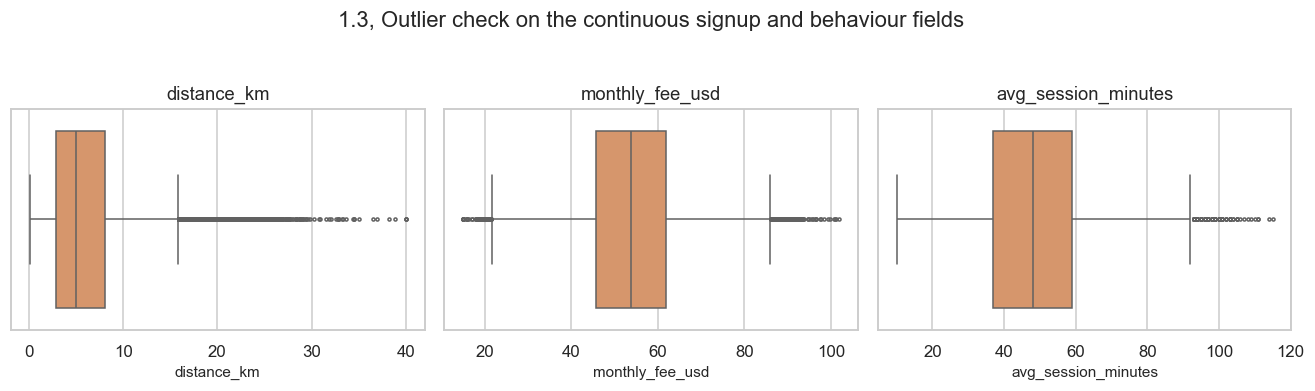

In [6]:
# Boxplots for the three continuous fields the client cares about
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, c in zip(axes, ["distance_km", "monthly_fee_usd", "avg_session_minutes"]):
    sns.boxplot(x=raw[c], ax=ax, color=ACCENT, fliersize=2)
    ax.set_title(c)
fig.suptitle("1.3, Outlier check on the continuous signup and behaviour fields", y=1.04)
plt.tight_layout()
plt.show()

**Observations**

- No missing values, no duplicate ids, no duplicate rows
- IQR flags 1,678 on `distance_km`, 242 on `monthly_fee_usd`, 1,200 to 2,300 on each visit column. Z score above 3 flags fewer since those columns are right skewed
- These are artifacts not errors (Week 3). A 40 km commute, a $101.89 premium plan and 14 visits in a week are all possible, and nothing is negative or impossible
- Keeping all 50,000 rows. Dropping the distance tail cuts the members the question is about, dropping the visit tail flattens what A and B rest on

## 2: Exploratory data analysis

### 2.1: The target

Churned by February: 22,560 of 50,000 members (45.12%)
Stayed: 27,440 (54.88%)


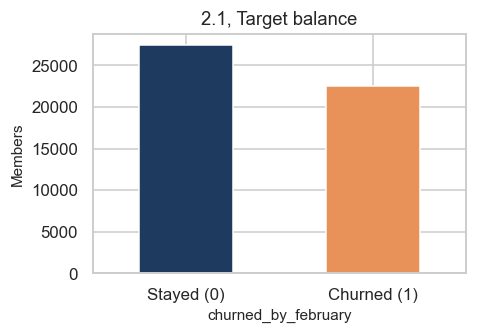

In [7]:
churn_rate = raw["churned_by_february"].mean()
n_churn = int(raw["churned_by_february"].sum())
print(f"Churned by February: {n_churn:,} of {len(raw):,} members ({churn_rate*100:.2f}%)")
print(f"Stayed: {len(raw)-n_churn:,} ({(1-churn_rate)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(4.5, 3.2))
raw["churned_by_february"].value_counts().sort_index().plot(kind="bar", ax=ax, color=[DARK, ACCENT], rot=0)
ax.set_xticklabels(["Stayed (0)", "Churned (1)"])
ax.set_ylabel("Members")
ax.set_title("2.1, Target balance")
plt.tight_layout()
plt.show()

**Observations**

- 22,560 of 50,000 ghosted, so churn is 45.12%. Matches the "nearly half" in the proposal
- Nearly balanced at 45 / 55, so accuracy is readable here unlike Assignment 2. Baseline is 54.88%
- Still reporting precision, recall, F1 and AUC since the two error types dont cost the same (Week 4)

### 2.2: Feature distributions

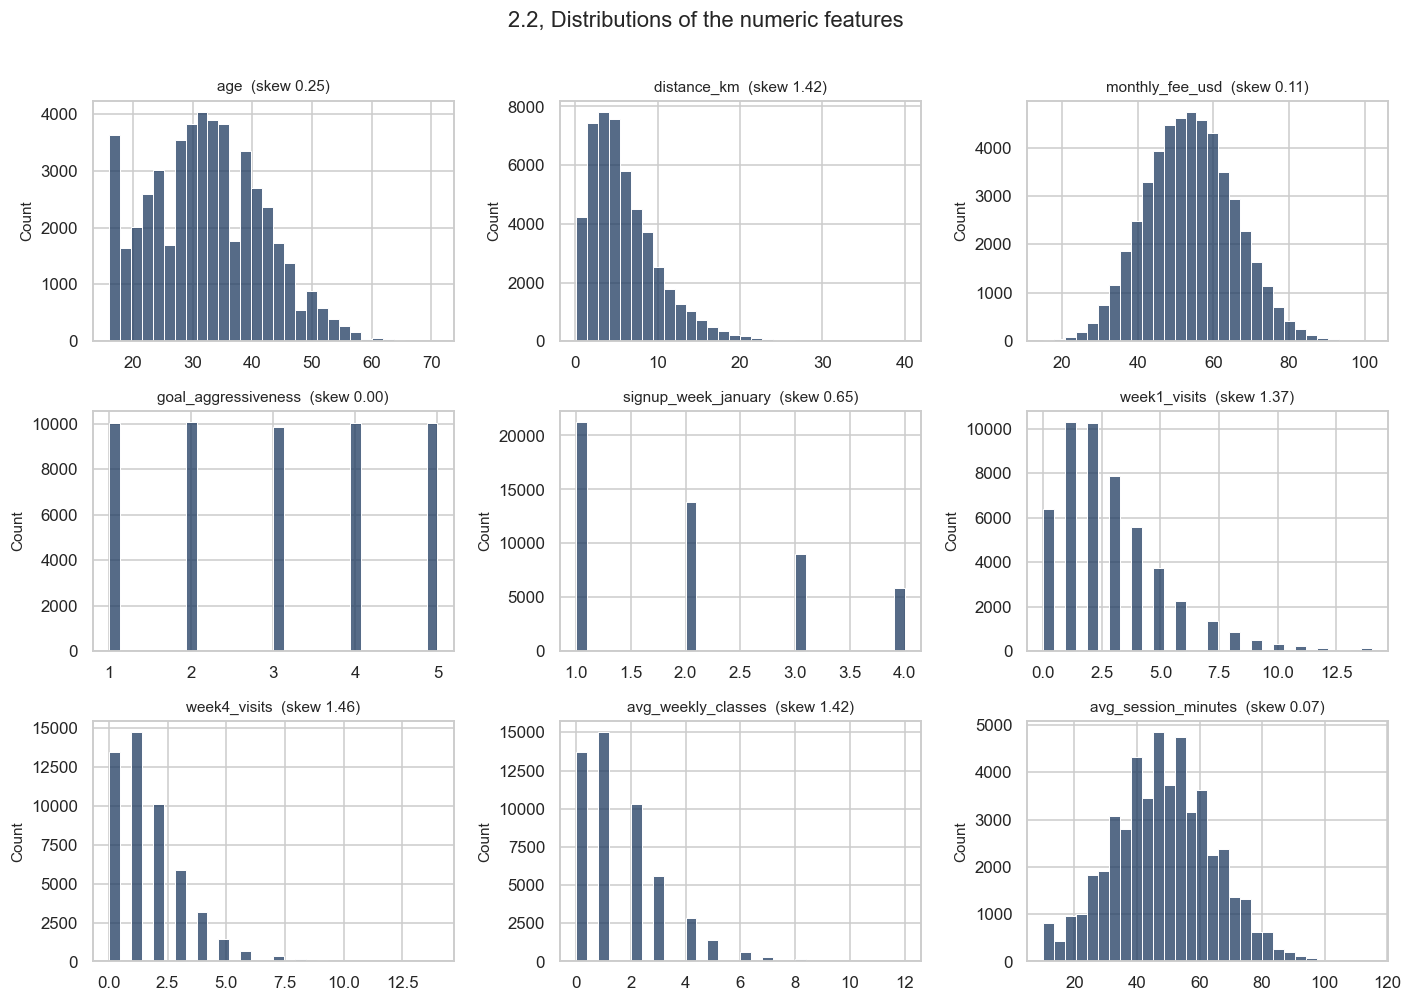

In [8]:
num_cols = ["age", "distance_km", "monthly_fee_usd", "goal_aggressiveness", "signup_week_january",
            "week1_visits", "week4_visits", "avg_weekly_classes", "avg_session_minutes"]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(raw[c], bins=30, ax=ax, color=DARK)
    ax.set_title(f"{c}  (skew {raw[c].skew():.2f})", fontsize=10)
    ax.set_xlabel("")
fig.suptitle("2.2, Distributions of the numeric features", y=1.01)
plt.tight_layout()
plt.show()

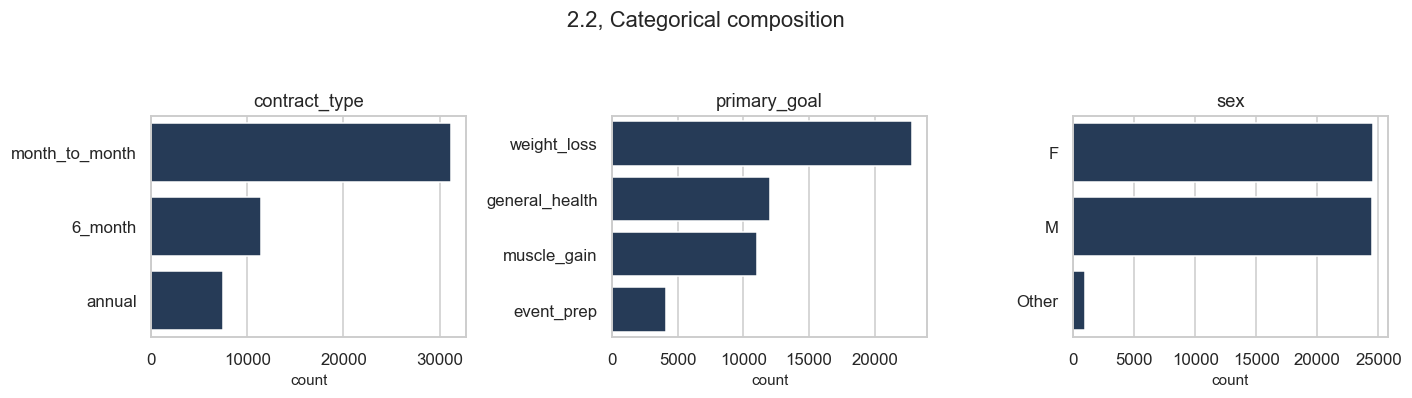


contract_type:
contract_type
month_to_month    62.4%
6_month           22.7%
annual            14.8%
Name: proportion, dtype: object

primary_goal:
primary_goal
weight_loss       45.7%
general_health    24.1%
muscle_gain       22.0%
event_prep         8.2%
Name: proportion, dtype: object

signup_week_january:
signup_week_january
1    42.5%
2    27.7%
3    18.1%
4    11.8%
Name: proportion, dtype: object


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, c in zip(axes, ["contract_type", "primary_goal", "sex"]):
    order = raw[c].value_counts().index
    sns.countplot(y=raw[c], order=order, ax=ax, color=DARK)
    ax.set_title(c)
    ax.set_ylabel("")
fig.suptitle("2.2, Categorical composition", y=1.06)
plt.tight_layout()
plt.show()

for c in ["contract_type", "primary_goal", "signup_week_january"]:
    print(f"\n{c}:")
    print((raw[c].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

**Observations**

- Age mildly right skewed (0.25) centred at 32, distance skewed 1.42 with median 5.0 km and a tail to 40, fee near symmetric (0.11) around $53.90
- `goal_aggressiveness` is dead flat, about 10,000 per level
- Signups front loaded, 42.5% in week 1 then 27.7%, 18.1%, 11.8%
- Contract mix 62.4% month_to_month, 22.7% 6_month, 14.8% annual. Biggest thing in here, and it is what the Phase 2 fee work has to control for
- Behaviour columns are the skewed ones. `avg_weekly_classes` skewed 1.42 with 13,684 (27.4%) at zero, already a problem for Option A

### 2.3: Missingness and the visit decay curve

Mean visits per week, stayers vs churners:
                     week1_visits  week2_visits  week3_visits  week4_visits
churned_by_february                                                        
0                           3.588         3.042         2.510         2.093
1                           1.853         1.590         1.307         1.071

Week 4 as a share of week 1:
churned_by_february
0    0.583
1    0.578
dtype: float64


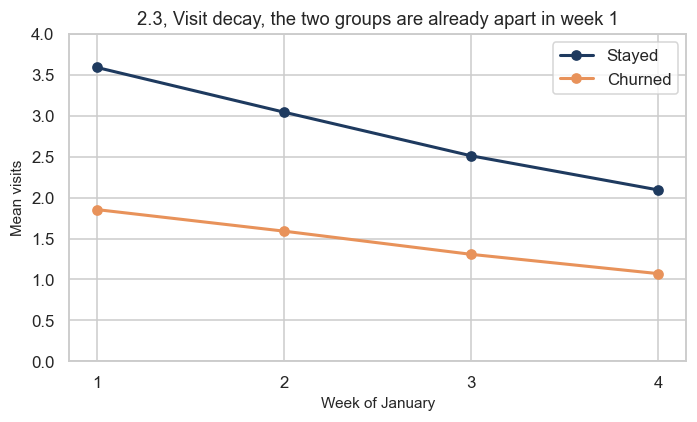

In [10]:
# Build the two derived visit features here since the rest of the EDA leans on them.
# reference: Week 5 slides, "Ratios & Interaction Features" (a ratio carries more signal than the raw counts)
df = raw.copy()
week_cols = [f"week{i}_visits" for i in range(1, 5)]
df["total_visits_m1"] = df[week_cols].sum(axis=1)
df["avg_weekly_visits"] = df["total_visits_m1"] / 4
df["visit_trend"] = df["week4_visits"] - df["week1_visits"]

decay = df.groupby("churned_by_february")[week_cols].mean()
print("Mean visits per week, stayers vs churners:")
print(decay.round(3))
print("\nWeek 4 as a share of week 1:")
print((decay[week_cols[3]] / decay[week_cols[0]]).round(3))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot([1, 2, 3, 4], decay.loc[0], marker="o", lw=2, color=DARK, label="Stayed")
ax.plot([1, 2, 3, 4], decay.loc[1], marker="o", lw=2, color=ACCENT, label="Churned")
ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel("Week of January")
ax.set_ylabel("Mean visits")
ax.set_ylim(0, 4)
ax.set_title("2.3, Visit decay, the two groups are already apart in week 1")
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

- Both groups decay at the same rate. Stayers 3.59 down to 2.09 (58.3% of week 1), churners 1.85 down to 1.07 (57.8%)
- So the difference is the starting point, not the slope. Churners start at half and never catch up
- Not a "members lose momentum in week 3" problem, a "they showed up half as often on day one" problem
- Anything starting mid month is trying to change a slope thats already identical. And the gap shows in week 1, so risk can be flagged after seven days rather than eight weeks

### 2.4: Churn rate by categorical feature

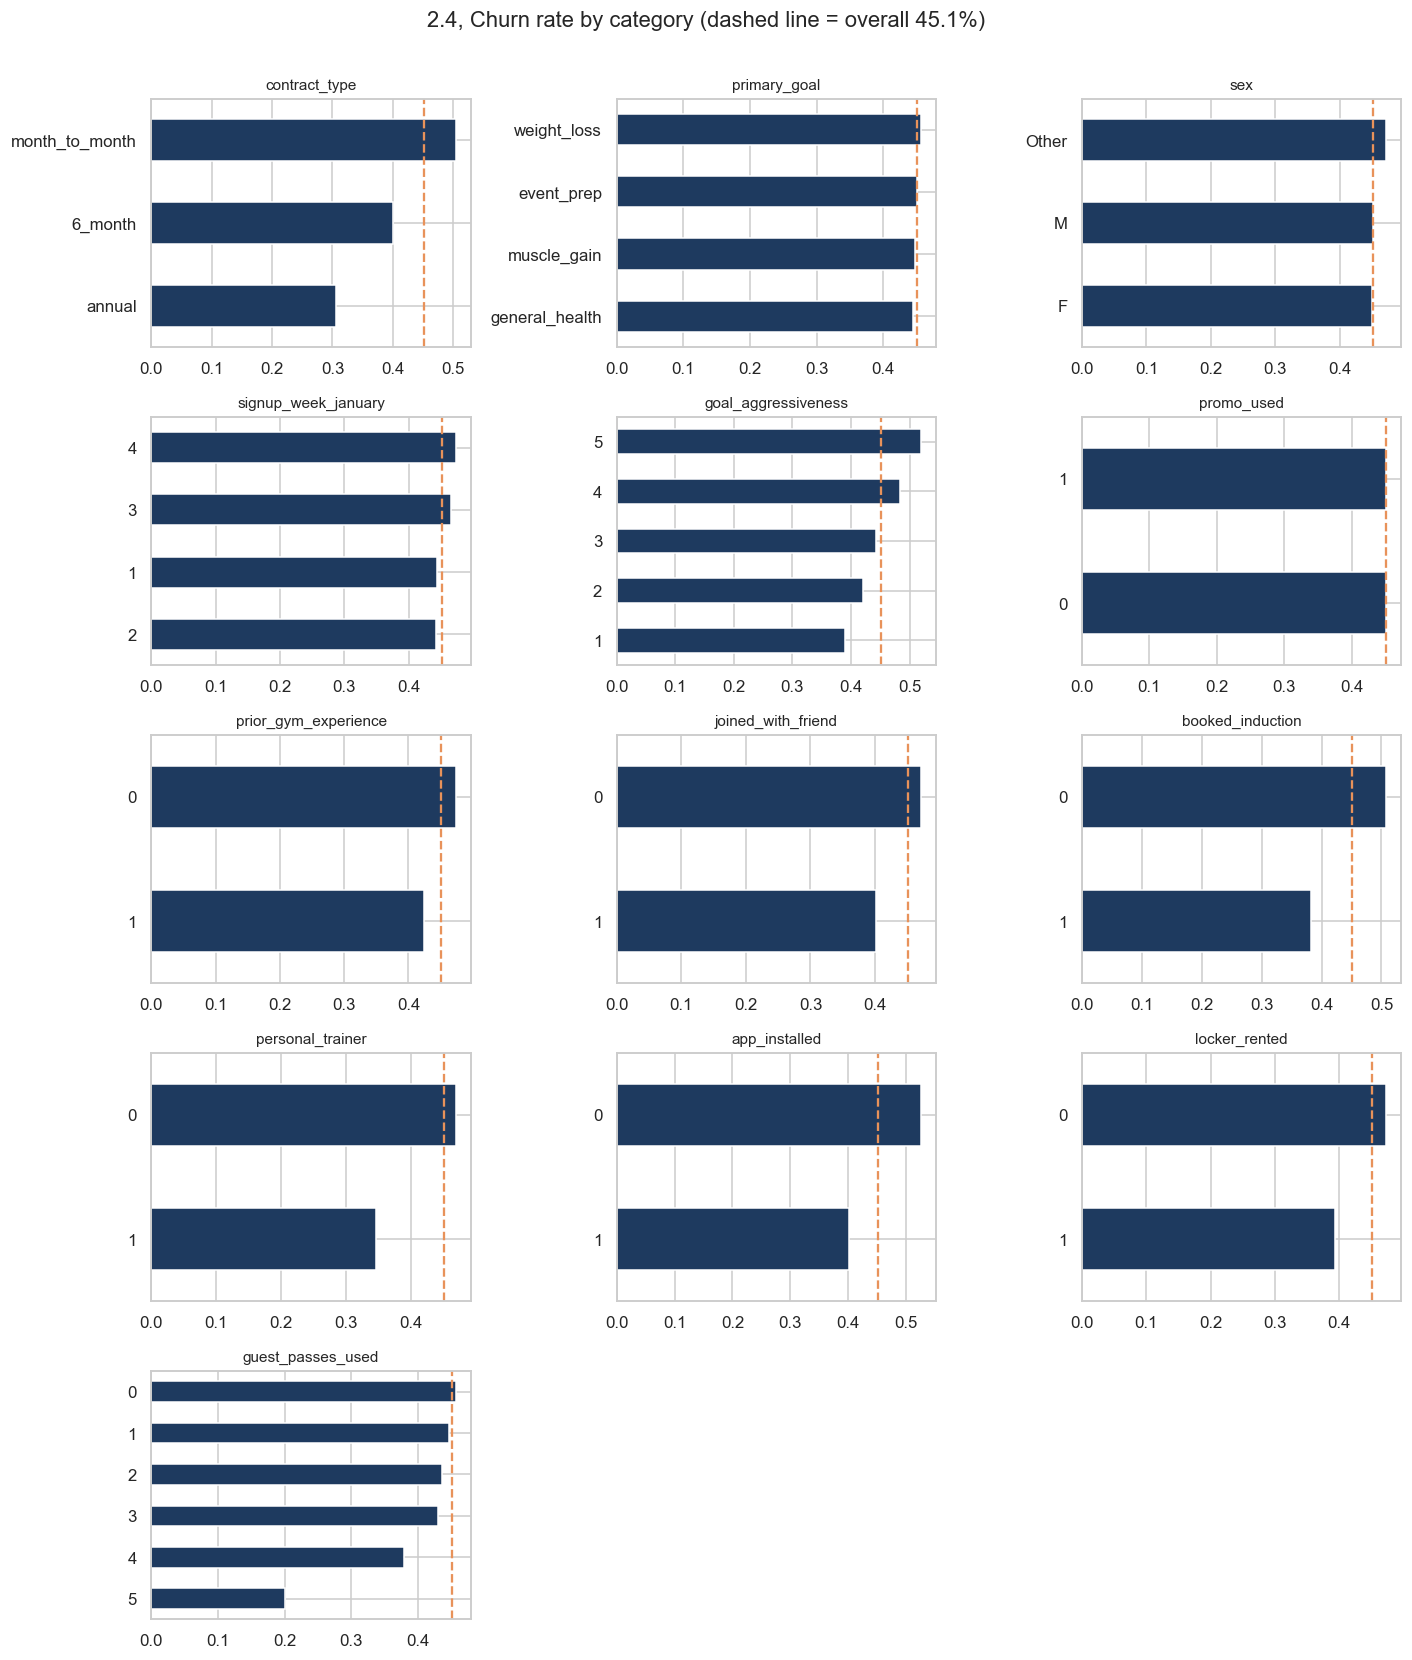


contract_type:
                churn_rate      n
contract_type                    
6_month              0.401  11363
annual               0.306   7417
month_to_month       0.504  31220

goal_aggressiveness:
                     churn_rate      n
goal_aggressiveness                   
1                         0.390  10016
2                         0.420  10065
3                         0.442   9867
4                         0.485  10041
5                         0.519  10011

booked_induction:
                  churn_rate      n
booked_induction                   
0                      0.508  27429
1                      0.382  22571

app_installed:
               churn_rate      n
app_installed                   
0                   0.526  19987
1                   0.402  30013

guest_passes_used:
                   churn_rate      n
guest_passes_used                   
0                       0.456  31133
1                       0.446  14429
2                       0.435   3681
3  

In [11]:
cat_cols = ["contract_type", "primary_goal", "sex", "signup_week_january", "goal_aggressiveness",
            "promo_used", "prior_gym_experience", "joined_with_friend", "booked_induction",
            "personal_trainer", "app_installed", "locker_rented", "guest_passes_used"]

fig, axes = plt.subplots(5, 3, figsize=(13, 15))
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
for ax, c in zip(axes.ravel(), cat_cols):
    g = df.groupby(c)["churned_by_february"].mean().sort_values()
    g.plot(kind="barh", ax=ax, color=DARK)
    ax.axvline(churn_rate, color=ACCENT, ls="--", lw=1.5)
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("2.4, Churn rate by category (dashed line = overall 45.1%)", y=1.005)
plt.tight_layout()
plt.show()

for c in ["contract_type", "goal_aggressiveness", "booked_induction", "app_installed",
          "guest_passes_used"]:
    g = df.groupby(c)["churned_by_february"].agg(["mean", "size"])
    g.columns = ["churn_rate", "n"]
    print(f"\n{c}:")
    print(g.round(3))

**Observations**

- `contract_type` separates most, annual 30.6%, 6_month 40.1%, month_to_month 50.4%. Known at signup
- `goal_aggressiveness` monotonic across all five, 39.0% to 51.9%
- First month flags all separate: induction 38.2% vs 50.8%, app 40.2% vs 52.6%, PT 34.7% vs 46.9%
- Weaker: prior experience 42.4% vs 47.3%, friend 40.1% vs 47.1%, locker 39.3% vs 47.3%. `guest_passes_used` 45.6% down to 43.0% but only 757 used three or more
- `promo_used` is 45.1% either way, which I did not expect. Sex flat, `primary_goal` only 44.4% to 45.6%
- `signup_week_january` 44.4% to 47.3%, small and the opposite way to what I expected

### 2.5: Correlation structure

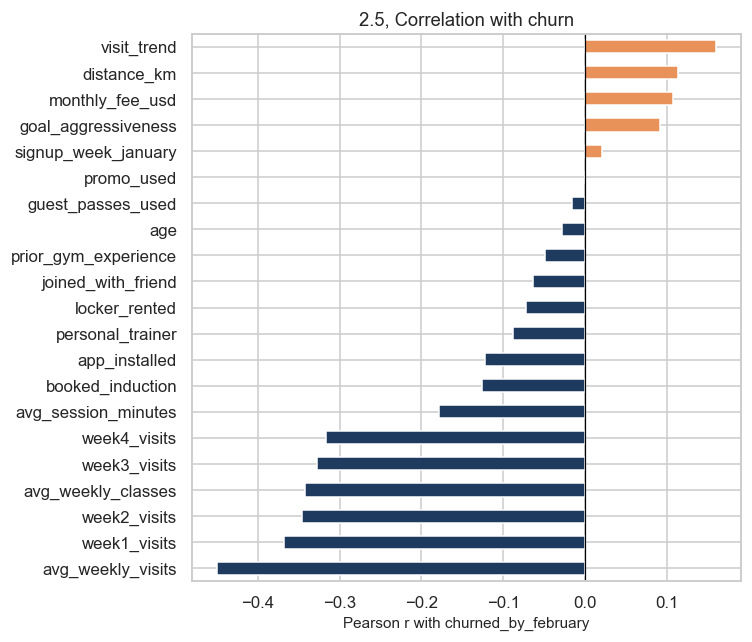

avg_weekly_visits      -0.451
week1_visits           -0.368
week2_visits           -0.346
avg_weekly_classes     -0.343
week3_visits           -0.327
week4_visits           -0.317
avg_session_minutes    -0.178
booked_induction       -0.126
app_installed          -0.122
personal_trainer       -0.088
locker_rented          -0.072
joined_with_friend     -0.063
prior_gym_experience   -0.049
age                    -0.028
guest_passes_used      -0.016
promo_used              0.001
signup_week_january     0.021
goal_aggressiveness     0.092
monthly_fee_usd         0.107
distance_km             0.113
visit_trend             0.161
Name: churned_by_february, dtype: float64


In [12]:
num = df.select_dtypes(include=[np.number]).drop(columns=["total_visits_m1"])
corr_target = num.corr()["churned_by_february"].drop("churned_by_february").sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = [ACCENT if v > 0 else DARK for v in corr_target]
corr_target.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with churned_by_february")
ax.set_title("2.5, Correlation with churn")
plt.tight_layout()
plt.show()

print(corr_target.round(3))

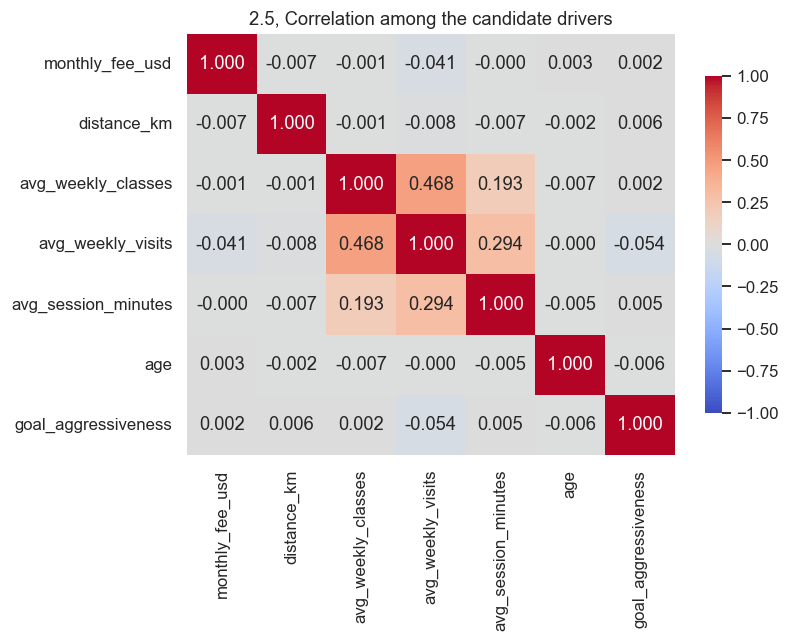

In [13]:
# Do the three candidate levers overlap with each other? 
levers = ["monthly_fee_usd", "distance_km", "avg_weekly_classes", "avg_weekly_visits",
          "avg_session_minutes", "age", "goal_aggressiveness"]
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(df[levers].corr(), annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("2.5, Correlation among the candidate drivers")
plt.tight_layout()
plt.show()

**Observations**

- Top is all behavioural: `avg_weekly_visits` -0.451, `week1_visits` -0.368, `week2_visits` -0.346, `avg_weekly_classes` -0.343, `avg_session_minutes` -0.178
- `visit_trend` +0.161, but only because members who start low have less room to fall
- Then a long way down, `distance_km` +0.113 and `monthly_fee_usd` +0.107. Naively that says A and B beat C by 4x, which is the trap section 3 is about
- The levers barely touch each other, fee vs classes -0.001, vs distance -0.007, vs visits -0.041. So one confounder to worry about, contract type
- Classes vs visits is +0.468 though. A and B arent independent, a class is also a visit

### 2.6: Continuous features split by the target

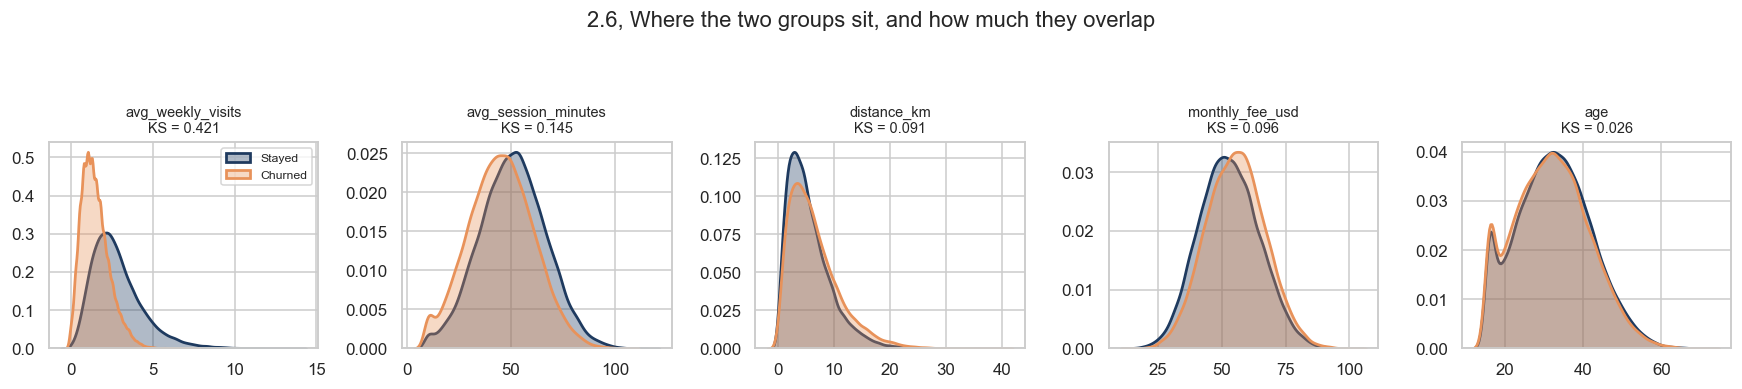

            feature  stayed_median  churned_median   stayed_IQR  churned_IQR    KS
  avg_weekly_visits           2.50            1.25   [1.8, 3.5]   [0.8, 2.0] 0.421
avg_session_minutes          51.00           45.00 [40.0, 61.0] [34.0, 56.0] 0.145
        distance_km           4.70            5.50   [2.7, 7.5]   [3.2, 8.8] 0.091
    monthly_fee_usd          52.39           55.26 [44.5, 60.7] [47.2, 63.0] 0.096
                age          32.00           32.00 [26.0, 39.0] [25.0, 38.0] 0.026


In [14]:
# The correlations in 2.5 are one number per feature. This is the same question drawn out:
# where do the two groups actually sit, and how much do they overlap?
from scipy.stats import ks_2samp

split_cols = ["avg_weekly_visits", "avg_session_minutes", "distance_km", "monthly_fee_usd", "age"]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, c in zip(axes, split_cols):
    for val, color, lab in [(0, DARK, "Stayed"), (1, ACCENT, "Churned")]:
        sns.kdeplot(df.loc[df["churned_by_february"] == val, c], ax=ax, color=color, fill=True, alpha=0.35, lw=1.8, label=lab)
    ks = ks_2samp(df.loc[df["churned_by_february"] == 1, c], df.loc[df["churned_by_february"] == 0, c]).statistic
    ax.set_title(f"{c}\nKS = {ks:.3f}", fontsize=9.5)
    ax.set_ylabel("")
    ax.set_xlabel("")
axes[0].legend(fontsize=8)
fig.suptitle("2.6, Where the two groups sit, and how much they overlap", y=1.10)
plt.tight_layout()
plt.show()

rows = []
for c in split_cols:
    g = df.groupby("churned_by_february")[c]
    rows.append({
        "feature": c,
        "stayed_median": round(g.median()[0], 2), "churned_median": round(g.median()[1], 2),
        "stayed_IQR": f"[{g.quantile(.25)[0]:.1f}, {g.quantile(.75)[0]:.1f}]",
        "churned_IQR": f"[{g.quantile(.25)[1]:.1f}, {g.quantile(.75)[1]:.1f}]",
        "KS": round(ks_2samp(df.loc[df["churned_by_february"] == 1, c],
                             df.loc[df["churned_by_february"] == 0, c]).statistic, 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

**Observations**

- KS is the biggest gap between the two cumulative distributions, 0 identical and 1 no overlap
- Only `avg_weekly_visits` really separates, KS 0.421, median 2.50 vs 1.25, IQRs [1.8, 3.5] vs [0.8, 2.0]
- `distance_km` 0.091 and `monthly_fee_usd` 0.096 are shifts, not separations. Medians 5.50 vs 4.70 km and $55.26 vs $52.39. The fee curves sit almost on top of each other, which is what Option C has to work with
- `avg_session_minutes` 0.145. `age` flat at 0.026, identical medians of 32
- Nothing cleanly splits this population, so there is a ceiling on any model here before anything is fitted

### 2.7: Fee, contract type and the confounding check

Monthly fee by contract type:
                count   mean  median
contract_type                       
6_month         11363  50.20   50.31
annual           7417  42.01   42.11
month_to_month  31220  58.08   58.09

Churn by fee quintile, raw:
                  mean   size
fee_q                        
(14.999, 43.76]  0.369  10006
(43.76, 50.61]   0.422  10012
(50.61, 56.8]    0.455   9989
(56.8, 63.89]    0.497   9998
(63.89, 101.89]  0.514   9995

Churn by fee quintile WITHIN contract type:
                                churn_rate     n
contract_type  fee_q                            
6_month        (14.999, 43.76]       0.390  2709
               (43.76, 50.61]        0.395  3141
               (50.61, 56.8]         0.400  2856
               (56.8, 63.89]         0.423  1939
               (63.89, 101.89]       0.409   718
annual         (14.999, 43.76]       0.298  4328
               (43.76, 50.61]        0.319  2023
               (50.61, 56.8]         0.316   798
           

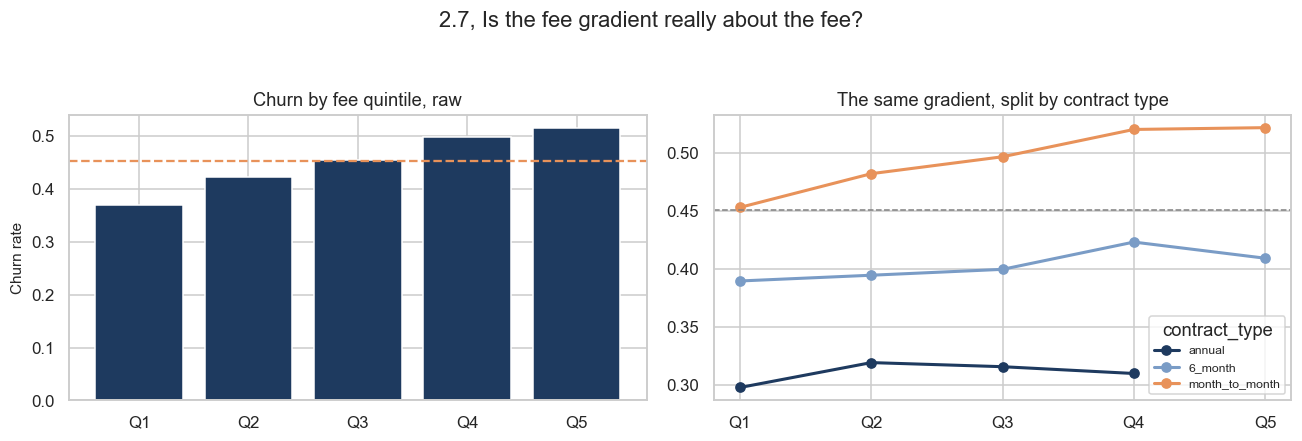

In [15]:
# The client asked specifically whether fee moves with contract type and promotion, so this
# is a descriptive check before any modelling. Pure crosstabs, no model.
df["fee_q"] = pd.qcut(df["monthly_fee_usd"], 5)

print("Monthly fee by contract type:")
print(df.groupby("contract_type")["monthly_fee_usd"].agg(["count", "mean", "median"]).round(2))

print("\nChurn by fee quintile, raw:")
print(df.groupby("fee_q", observed=True)["churned_by_february"].agg(["mean", "size"]).round(3))

print("\nChurn by fee quintile WITHIN contract type:")
within = df.groupby(["contract_type", "fee_q"], observed=True)["churned_by_february"].agg(["mean", "size"])
within.columns = ["churn_rate", "n"]
print(within.round(3))

print("\nPromotion, the other thing the client named:")
print(df.groupby("promo_used")[["monthly_fee_usd", "churned_by_february"]].mean().round(4))
print("promo uptake within contract type:")
print(df.groupby("contract_type")["promo_used"].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = df.groupby("fee_q", observed=True)["churned_by_february"].mean()
axes[0].bar(range(5), g.values, color=DARK)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels([f"Q{i+1}" for i in range(5)])
axes[0].axhline(churn_rate, color=ACCENT, ls="--", lw=1.5)
axes[0].set_title("Churn by fee quintile, raw")
axes[0].set_ylabel("Churn rate")

for ct, color in zip(["annual", "6_month", "month_to_month"], [DARK, "#7a9cc6", ACCENT]):
    sub = within.loc[ct]; sub = sub[sub["n"] >= 100]
    axes[1].plot(range(len(sub)), sub["churn_rate"], marker="o", lw=2, color=color, label=ct)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels([f"Q{i+1}" for i in range(5)])
axes[1].axhline(churn_rate, color="grey", ls="--", lw=1)
axes[1].set_title("The same gradient, split by contract type")
axes[1].legend(title="contract_type", fontsize=8)
fig.suptitle("2.7, Is the fee gradient really about the fee?", y=1.05)
plt.tight_layout()
plt.show()

**Observations**

- Raw fee gradient climbs across quintiles, 36.9%, 42.2%, 45.5%, 49.7%, 51.4%. On its own that reads as "expensive members leave"
- But month to month pays the most ($58.08) and churns the most (50.4%), while annual pays the least ($42.01) and churns the least (30.6%). So a lot of it is really the contract, not the price
- Split inside contract type and most of it goes. 6_month 39.0% to 42.3% and not monotonic, annual 29.8% to 31.9%, month_to_month 45.3% to 52.2%. Something survives but its about half the raw size and it sits in month to month
- Promotion is not a second confounder. Promo users pay $53.88 and non users $53.93, they churn at 45.14% vs 45.09%, and uptake is 54% to 56% in every contract type
- This is the thing the client warned about in their third answer, and it has to be handled properly in Phase 2 rather than left as a crosstab

## 3: Direction for each problem

Both problems get a supervised approach. The reasoning differs between them, so I set out each one separately.

### 3.1: Problem 1 (Phase 1), which option does the data support?

**Direction:** supervised, and explanatory rather than predictive

**Reasoning:**

`churned_by_february` exists for all 50,000 members and its exactly what leadership cares about, so unsupervised is out. Clustering would just give me groups defined by whatever dominates the scaled feature space and Id have to check each one against the churn label anyway, which is a longer road to the same place. Within supervised theres still a choice between explanatory and predictive, and this problem asks which of three interventions the data supports rather than what a given member does next. Thats a question about mechanism, so I use group churn rates, effect sizes and a permutation test, and leave the classifier for Problem 2. One thing I add that the brief doesnt mention is that a correlation is only a lever if the gym can move it, so I also score each option on whether its known before the member behaves and whether the gym can change it at all. The EDA already hints thats what separates the three, since classes and visits are measured inside the churn window while the fee is set at signup.

### 3.2: Problem 2 (Phase 2), how much does the fee drive churn?

**Direction:** supervised classification, logistic regression as the primary model

**Reasoning:**

The target is labelled and binary so this is a classifier and not a regressor, and unsupervised is out for the same reason as Problem 1. The real choice is logistic regression against a tree ensemble and I go with logistic, because the client needs two different things out of one model. The coefficients convert to odds ratios reading as each extra dollar multiplying the odds of churning by some amount, which is what prices a decision, while a forest only gives a feature ranking that cant say what a $10 change does. The client also confirmed the model has to be something management can follow, which settles it, and Ill fit a forest and a booster anyway as a check. The objective is retained revenue rather than churn, since minimising churn on its own is degenerate when the cheapest way to hit it is giving memberships away. Isolating the fee is then a matter of nested models, watching the coefficient move as contract type and the signup controls go in, which 2.7 shows is necessary. Metrics are precision, recall, F1 and AUC with the threshold tuned rather than left at 0.5, since a false negative is a lost membership and a false positive is one email.

## 4: Problem 1, which option does the data support?

The three options assessed against the data. The direction and the reasoning for treating this as explanatory rather than predictive are in 3.1.

### 4.1: Option A, reward class attendance

Churn rate by average weekly classes:
                    churn_rate      n
avg_weekly_classes                   
0                        0.653  13684
1                        0.519  15003
2                        0.370  10282
3                        0.252   5574
4                        0.162   2871
5                        0.082   1389
6                        0.054    643
7                        0.056    302
8                        0.015    133
9                        0.016     63
10                       0.000     25
11                       0.000     16
12                       0.000     15


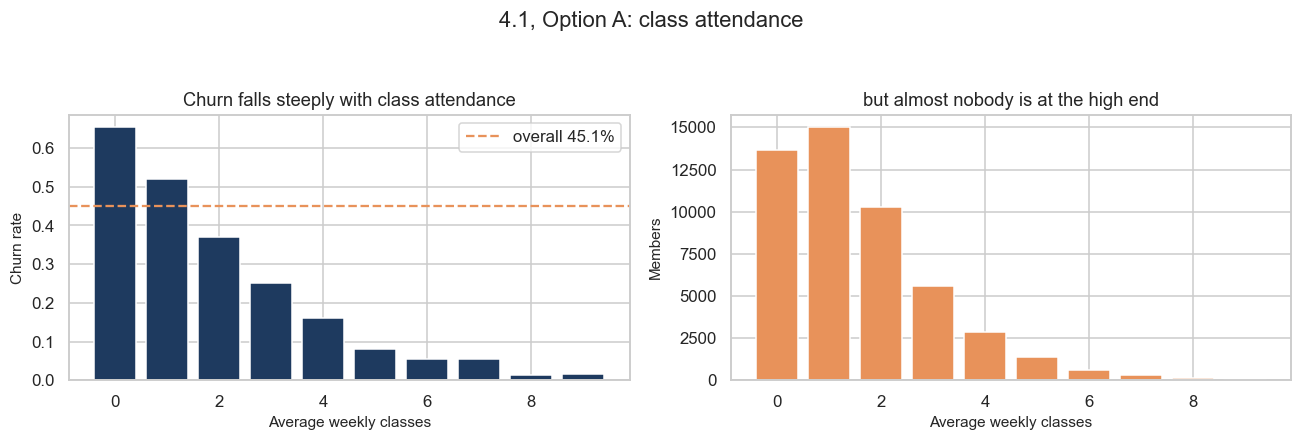


Members taking zero classes: 13,684 (27.4%), churn 0.653
Share of ALL churners who took zero classes: 39.6%
Members at >= 1 class/wk: 36,316 (72.6%), churn 0.375
Members at >= 3 class/wk: 11,031 (22.1%), churn 0.185


In [16]:
# Option A: does class attendance separate churn, and can a reward reach the people
# who are leaving? Group churn rates first, then the size of each group, because a
# reward is only worth funding if the group it targets is the group that churns.
# reference: Week 6 slides, "Now imagine two groups" (compare the groups before
#            testing anything about them)
opt_a = df.groupby("avg_weekly_classes")["churned_by_february"].agg(["mean", "size"])
opt_a.columns = ["churn_rate", "n"]
print("Churn rate by average weekly classes:")
print(opt_a.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sub = opt_a[opt_a["n"] >= 50]
axes[0].bar(sub.index, sub["churn_rate"], color=DARK)
axes[0].axhline(churn_rate, color=ACCENT, ls="--", lw=1.5, label="overall 45.1%")
axes[0].set_xlabel("Average weekly classes")
axes[0].set_ylabel("Churn rate")
axes[0].set_title("Churn falls steeply with class attendance")
axes[0].legend()

axes[1].bar(sub.index, sub["n"], color=ACCENT)
axes[1].set_xlabel("Average weekly classes")
axes[1].set_ylabel("Members")
axes[1].set_title("but almost nobody is at the high end")
fig.suptitle("4.1, Option A: class attendance", y=1.05)
plt.tight_layout()
plt.show()

zero = df["avg_weekly_classes"] == 0
print(f"\nMembers taking zero classes: {zero.sum():,} ({zero.mean()*100:.1f}%), churn {df.loc[zero,'churned_by_february'].mean():.3f}")
print(f"Share of ALL churners who took zero classes: "
      f"{df.loc[zero,'churned_by_february'].sum() / n_churn * 100:.1f}%")
for thr in [1, 3]:
    hit = df["avg_weekly_classes"] >= thr
    print(f"Members at >= {thr} class/wk: {hit.sum():,} ({hit.mean()*100:.1f}%), churn {df.loc[hit,'churned_by_february'].mean():.3f}")

**Interpretation (4.1):**

- Real and steep. Churn is 65.3% at zero classes a week, then 51.9%, 37.0%, 25.2%, 16.2% and 8.2%. Cohens d is -0.733.
- But Option A rewards everyone for attending, so the group it has to move is the group not attending. 13,684 members (27.4%) took zero classes and churn at 65.3%, and 39.6% of all churners never set foot in a class. A reward for attending cant be collected by someone who isnt there.
- The members it does pay out to are mostly staying anyway. 11,031 (22.1%) already average three or more classes and churn at 18.5%.
- Direction problem too. Classes are measured over the same four weeks the member decides to ghost, so low attendance is partly a symptom. Same post treatment issue as `ai_suggestions_used` in Assignment 2.
- **Verdict on A: weak.** Aimed at the wrong 22%, misses 40% of churners, and the direction is unresolvable.

### 4.2: Option B, punch card for 3 visits a week

Churn rate by average weekly visits:
            churn_rate      n
visit_band                   
0                0.827   4342
0.5-1            0.721   7698
1-1.5            0.596   8724
1.5-2            0.476   7906
2-3              0.308  10987
3-4              0.163   5433
4+               0.038   4910


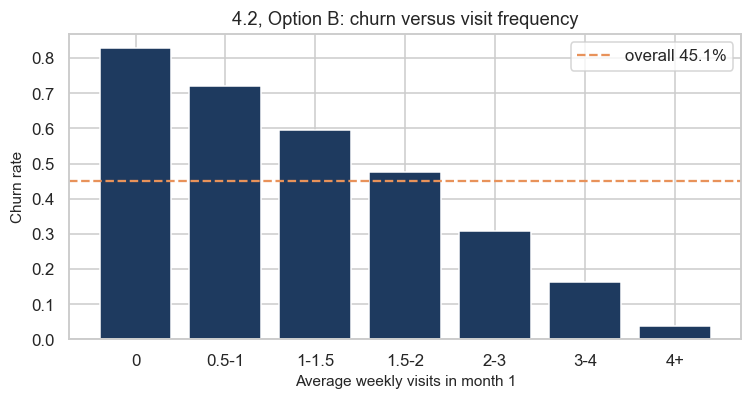


Punch card target is 3 visits a week. Who can reach it?
  averaged >= 3 visits/wk over the month : 12,483 (25.0%), churn 0.126
  hit 3 visits in ALL FOUR weeks         : 3,746 (7.5%), churn 0.051
  ever hit 3 in a single week            : 69.2%

  below the target: 37,517 (75.0%), churn 0.560
  share of ALL churners who never averaged 3/wk: 93.0%

If the target were 2 visits a week instead:
  at or above: 25,013 (50.0%), churn 0.243
  below      : 24,987 (50.0%), churn 0.660


In [17]:
# Option B: same two questions for visit frequency. The client already fixed the
# target at 3 visits a week, so the second half of this cell checks how many members
# can actually reach that bar.
# reference: Week 5 slides, "Binning" (pd.cut, continuous visits into readable bands)
df["visit_band"] = pd.cut(df["avg_weekly_visits"], [-0.01, 0.5, 1, 1.5, 2, 3, 4, 20],
                          labels=["0", "0.5-1", "1-1.5", "1.5-2", "2-3", "3-4", "4+"])
opt_b = df.groupby("visit_band", observed=True)["churned_by_february"].agg(["mean", "size"])
opt_b.columns = ["churn_rate", "n"]
print("Churn rate by average weekly visits:")
print(opt_b.round(3))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(opt_b.index.astype(str), opt_b["churn_rate"], color=DARK)
ax.axhline(churn_rate, color=ACCENT, ls="--", lw=1.5, label="overall 45.1%")
ax.set_xlabel("Average weekly visits in month 1")
ax.set_ylabel("Churn rate")
ax.set_title("4.2, Option B: churn versus visit frequency")
ax.legend()
plt.tight_layout()
plt.show()

# Can members actually reach the punch card target of 3 visits a week?
wk = df[week_cols]
print(f"\nPunch card target is 3 visits a week. Who can reach it?")
print(f"  averaged >= 3 visits/wk over the month : {(df['avg_weekly_visits']>=3).sum():,} "
      f"({(df['avg_weekly_visits']>=3).mean()*100:.1f}%), churn {df.loc[df['avg_weekly_visits']>=3,'churned_by_february'].mean():.3f}")
print(f"  hit 3 visits in ALL FOUR weeks         : {(wk>=3).all(axis=1).sum():,} "
      f"({(wk>=3).all(axis=1).mean()*100:.1f}%), churn {df.loc[(wk>=3).all(axis=1),'churned_by_february'].mean():.3f}")
print(f"  ever hit 3 in a single week            : {(wk>=3).any(axis=1).mean()*100:.1f}%")
below = df["avg_weekly_visits"] < 3
print(f"\n  below the target: {below.sum():,} ({below.mean()*100:.1f}%), churn {df.loc[below,'churned_by_february'].mean():.3f}")
print(f"  share of ALL churners who never averaged 3/wk: "
      f"{df.loc[below,'churned_by_february'].sum() / n_churn * 100:.1f}%")

# What would a reachable target look like instead?
hit2 = df["avg_weekly_visits"] >= 2
print(f"\nIf the target were 2 visits a week instead:")
print(f"  at or above: {hit2.sum():,} ({hit2.mean()*100:.1f}%), churn {df.loc[hit2,'churned_by_february'].mean():.3f}")
print(f"  below      : {(~hit2).sum():,} ({(~hit2).mean()*100:.1f}%), churn {df.loc[~hit2,'churned_by_february'].mean():.3f}")

In [18]:
# Do Options A and B point at different people, or the same people twice?
# reference: Week 6 slides, "Why coefficients change when you add predictors"
df["vb"] = pd.cut(df["avg_weekly_visits"], [-0.01, 1, 2, 3, 20], labels=["0-1", "1-2", "2-3", "3+"]).astype(str)
df["cb"] = pd.cut(df["avg_weekly_classes"], [-0.01, 0, 1, 2, 20], labels=["0", "1", "2", "3+"]).astype(str)

print("Churn rate, rows = visits/wk band, cols = classes/wk band:")
print(pd.crosstab(df["vb"], df["cb"], values=df["churned_by_february"], aggfunc="mean").round(3))
print("\nCell counts:")
print(pd.crosstab(df["vb"], df["cb"]))

# and as nested logistic models
d_ = df.copy()
for label, cols in [("visits only", ["avg_weekly_visits"]),
                    ("classes only", ["avg_weekly_classes"]),
                    ("visits + classes", ["avg_weekly_visits", "avg_weekly_classes"])]:
    X_ = sm.add_constant(d_[cols].astype(float))
    m_ = sm.Logit(d_["churned_by_february"], X_).fit(disp=0)
    print(f"\n{label}: pseudo R2 = {m_.prsquared:.4f}")
    print(pd.DataFrame({"beta": m_.params, "OR": np.exp(m_.params)}).round(4))

Churn rate, rows = visits/wk band, cols = classes/wk band:
cb       0      1      2     3+
vb                             
0-1  0.828  0.758  0.680  0.519
1-2  0.652  0.574  0.466  0.337
2-3  0.453  0.354  0.267  0.171
3+   0.221  0.165  0.101  0.053

Cell counts:
cb      0     1     2    3+
vb                         
0-1  5289  4069  1801   881
1-2  5066  5537  3501  2526
2-3  2255  3324  2665  2743
3+   1074  2073  2315  4881



visits only: pseudo R2 = 0.1948
                     beta      OR
const              1.8217  6.1823
avg_weekly_visits -1.0134  0.3630

classes only: pseudo R2 = 0.0985
                      beta      OR
const               0.6400  1.8966
avg_weekly_classes -0.5788  0.5606

visits + classes: pseudo R2 = 0.2219
                      beta      OR
const               2.0994  8.1614
avg_weekly_visits  -0.8940  0.4090
avg_weekly_classes -0.3680  0.6921


**Interpretation (4.2):**

- Steeper than A. Churn is 82.7% under half a visit a week and 3.8% at four or more. Cohens d is -1.014, the largest in the dataset.
- But the client set the target at three visits a week. Only 12,483 members (25.0%) averaged it, and only 3,746 (7.5%) hit three in all four weeks, which is what a punch card needs.
- 93.0% of all churners never averaged three, so the reward is unreachable for the group its meant to keep. A target of two would split the cohort in half, 50.0% above churning at 24.3% against 50.0% below at 66.0%.
- A and B arent separate. Visits alone gives pseudo R2 0.195, classes alone 0.099, both 0.222, so classes on top of visits only buys 0.027.
- The client confirmed churn pools cancelled with stopped attending, so churned is partly defined by not showing up while A and B are scored on showing up. That makes -1.014 an upper bound. The fee has no such problem.
- **Verdict on B: weak.** Unreachable for 93% of churners, overlaps A, and part of its strength is circular.

### 4.3: Option C, price, and the distance check

Churn by distance band:
            mean   size
dist_band              
(0, 2]     0.391   7545
(2, 4]     0.412  11927
(4, 6]     0.436  10400
(6, 8]     0.466   7497
(8, 12]    0.500   8015
(12, 50]   0.577   4616

Distance against the other candidate levers:
distance_km           1.000
monthly_fee_usd      -0.007
avg_weekly_classes   -0.001
avg_weekly_visits    -0.008
Name: distance_km, dtype: float64


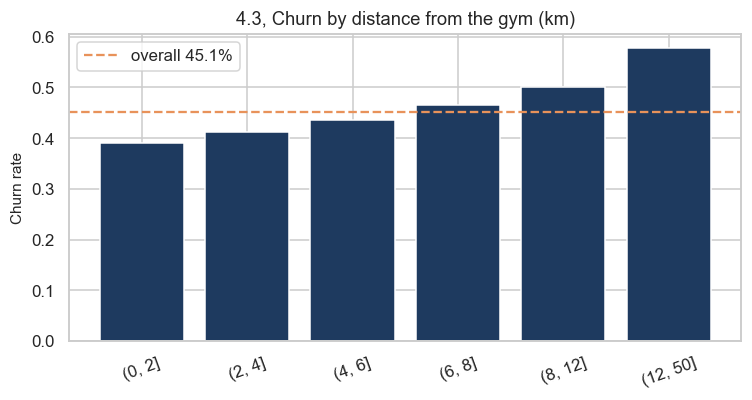

In [19]:
# reference: Week 3 slides, "Binning" for the distance bands
# The fee and contract type confounding is already covered in 2.7, so this is the
# distance check, which is the one Phase 1 variable fixed at signup and uncorrelated
# with everything else.
df["dist_band"] = pd.cut(df["distance_km"], [0, 2, 4, 6, 8, 12, 50])
print("Churn by distance band:")
print(df.groupby("dist_band", observed=True)["churned_by_february"].agg(["mean", "size"]).round(3))

print("\nDistance against the other candidate levers:")
print(df[["distance_km", "monthly_fee_usd", "avg_weekly_classes", "avg_weekly_visits"]]
      .corr()["distance_km"].round(3))

fig, ax = plt.subplots(figsize=(7, 3.8))
g = df.groupby("dist_band", observed=True)["churned_by_february"].mean()
ax.bar(range(len(g)), g.values, color=DARK)
ax.set_xticks(range(len(g)))
ax.set_xticklabels([str(i) for i in g.index], rotation=20)
ax.axhline(churn_rate, color=ACCENT, ls="--", lw=1.5, label="overall 45.1%")
ax.set_ylabel("Churn rate")
ax.set_title("4.3, Churn by distance from the gym (km)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (4.3):**

- The fee side of Option C is already done in 2.7. The raw gradient runs 36.9% to 51.4% across quintiles, but contract type sits underneath it and most of it flattens once you hold that constant. Promotion is not a second confounder.
- Distance is the clean control. It's fixed at signup and uncorrelated with everything else, -0.007 with fee and -0.001 with classes, so nothing is confounding it.
- Churn runs 39.1% under 2 km up to 57.7% beyond 12 km, an 18.6 point spread. That is wider than the raw fee spread and it has no confounding to strip out.
- Nobody moves house for a gym though, so distance is a targeting variable and not a lever.
- **Verdict on C: smallest correlation of the three and the only actual lever.** Set before the member behaves and controlled by leadership. The size question is Problem 2.

### 4.4: Effect sizes and a significance check

In [20]:
# Week 6: p tells you IF, effect size tells you HOW MUCH. Report both.
# reference: Week 6 slides, "Effect size: how big is the difference?" and "Permutation test"
def cohens_d(col):
    a = df.loc[df["churned_by_february"] == 1, col]
    b = df.loc[df["churned_by_february"] == 0, col]
    sp = np.sqrt(((len(a)-1)*a.var() + (len(b)-1)*b.var()) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp, a.mean(), b.mean()

rows = []
for c in ["avg_weekly_visits", "avg_weekly_classes", "avg_session_minutes",
          "distance_km", "monthly_fee_usd", "goal_aggressiveness", "age"]:
    d_val, m1, m0 = cohens_d(c)
    rows.append({"feature": c, "churned_mean": round(m1, 2), "stayed_mean": round(m0, 2),
                 "cohens_d": round(d_val, 3)})
eff = pd.DataFrame(rows).sort_values("cohens_d", key=abs, ascending=False)
print(eff.to_string(index=False))

            feature  churned_mean  stayed_mean  cohens_d
  avg_weekly_visits          1.46         2.81    -1.014
 avg_weekly_classes          0.99         2.06    -0.733
avg_session_minutes         44.95        50.70    -0.364
        distance_km          6.56         5.58     0.229
    monthly_fee_usd         55.29        52.76     0.217
goal_aggressiveness          3.14         2.88     0.186
                age         31.93        32.48    -0.057


Observed fee gap (churned minus stayed): $2.53
Null distribution: mean -0.0061, sd 0.1035
Permutation p value over 2000 shuffles: 0.0000  (0 of 2000 shuffles reached the observed gap)


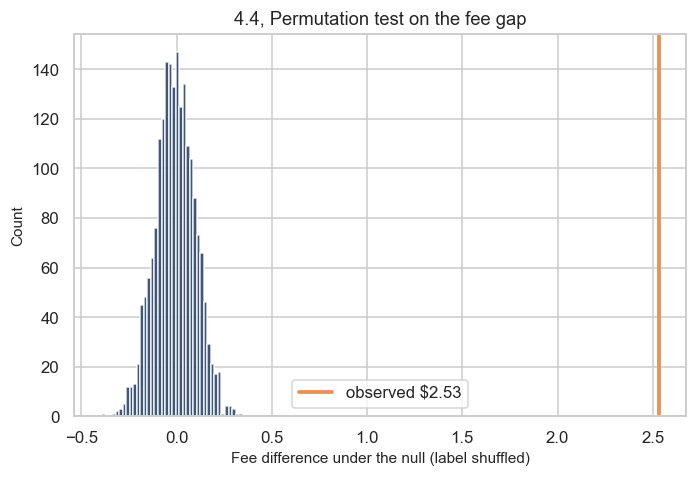

In [21]:
# Permutation test on the fee difference: is a $2.53 gap bigger than chance?
# reference: Week 6 slides, "Permutation test - the skeptic's move"
rng = np.random.default_rng(RANDOM_STATE)
lab = df["churned_by_february"].values.astype(bool)
fee = df["monthly_fee_usd"].values
observed = fee[lab].mean() - fee[~lab].mean()

perm = np.empty(2000)
for i in range(2000):
    p = rng.permutation(lab)
    perm[i] = fee[p].mean() - fee[~p].mean()

p_val = (np.abs(perm) >= abs(observed)).mean()
print(f"Observed fee gap (churned minus stayed): ${observed:.2f}")
print(f"Null distribution: mean {perm.mean():.4f}, sd {perm.std():.4f}")
print(f"Permutation p value over 2000 shuffles: {p_val:.4f}"
      + ("  (0 of 2000 shuffles reached the observed gap)" if p_val == 0 else ""))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.hist(perm, bins=40, color=DARK, alpha=0.85)
ax.axvline(observed, color=ACCENT, lw=2.5, label=f"observed ${observed:.2f}")
ax.set_xlabel("Fee difference under the null (label shuffled)")
ax.set_ylabel("Count")
ax.set_title("4.4, Permutation test on the fee gap")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (4.4):**

- By Cohens d: visits -1.014, classes -0.733, session minutes -0.364, distance +0.229, fee +0.217, goal aggressiveness +0.186, age -0.057. So the behavioural options are three to five times larger than price.
- The permutation test answers something else. Churners pay $55.29 and stayers $52.76, a $2.53 gap. Shuffling labels 2,000 times gives a null with sd about $0.10 and no shuffle came near it, so p < 0.0005.
- Thats the Week 6 statistical versus practical significance point. At n = 50,000 nearly anything is significant, and $2.53 clears the bar while being small enough it may not be worth acting on. Whether its worth $6M a year is 5.8.

### 4.5: Problem 1 verdict

In [22]:
# Phase 1 scorecard. Effect size on its own does not decide this, so each option is
# also scored on whether the variable is known before the member behaves and whether
# the gym can move it. Cohen's d values are carried over from 4.4.
# reference: Week 6 slides, "Statistical vs. practical significance"
summary = pd.DataFrame([
    {"option": "A: reward classes", "variable": "avg_weekly_classes",
     "cohens_d": -0.733, "churn_spread": "65.3% -> 8.2%",
     "known_at_signup": "No", "gym_can_change_it": "Indirectly",
     "reaches_the_churners": "No, 39.6% of churners took zero classes"},
    {"option": "B: 3x/wk punch card", "variable": "avg_weekly_visits",
     "cohens_d": -1.014, "churn_spread": "82.7% -> 3.8%",
     "known_at_signup": "No", "gym_can_change_it": "Indirectly",
     "reaches_the_churners": "No, 93.0% of churners never averaged 3/wk"},
    {"option": "C: adjust pricing", "variable": "monthly_fee_usd",
     "cohens_d": 0.217, "churn_spread": "36.9% -> 51.4%",
     "known_at_signup": "Yes", "gym_can_change_it": "Yes, directly",
     "reaches_the_churners": "Yes, every member pays a fee"},
    {"option": "(reference) distance", "variable": "distance_km",
     "cohens_d": 0.229, "churn_spread": "39.1% -> 57.7%",
     "known_at_signup": "Yes", "gym_can_change_it": "No",
     "reaches_the_churners": "Targeting only"},
])
summary.set_index("option")

,variable,cohens_d,churn_spread,known_at_signup,gym_can_change_it,reaches_the_churners
option,,,,,,
A: reward classes,avg_weekly_classes,-0.733,65.3% -> 8.2%,No,Indirectly,"No, 39.6% of churners took zero classes"
B: 3x/wk punch card,avg_weekly_visits,-1.014,82.7% -> 3.8%,No,Indirectly,"No, 93.0% of churners never averaged 3/wk"
C: adjust pricing,monthly_fee_usd,0.217,36.9% -> 51.4%,Yes,"Yes, directly","Yes, every member pays a fee"
(reference) distance,distance_km,0.229,39.1% -> 57.7%,Yes,No,Targeting only


**Problem 1 verdict**

- A and B are weaker than they look for the same reasons. Measured during the churn window, behaviours rather than decisions, and aimed at members already staying. A cant reach the 39.6% of churners who never took a class, B sets a target 93.0% never reached, and they overlap at r = 0.468 so funding both pays twice.
- Section 2.3 is the strongest evidence. The groups were already apart in week 1 at the same decay rate, so the difference these programmes are meant to create was there before either could start.
- C has the smallest correlation and is the only real lever. Set at signup before the member behaves, applies to every member, changeable by decision.
- So proceed to Option C, as the only testable option rather than the biggest effect. Caveat on the record: the effect is half raw size once contract type is held constant and lives in month to month, so no chain wide change.

## 5: Problem 2, predict churn and isolate the fee effect

The model, then the fee effect pulled out of it on its own, then the retained revenue curve the client asked for. The reasoning for logistic regression is in 3.2.

### 5.1: Feature engineering

In [23]:
# Week 5 feature engineering. Three derived features, everything else is used as given.
# reference: Week 5 slides, "Ratios & Interaction Features" and "One-Hot Encoding, code"
model_df = df.copy()

# 1. avg_weekly_visits: the four weekly counts collapsed into one rate. Built in 2.3.
# 2. visit_trend: week 4 minus week 1, so a negative value is a member losing momentum. Built in 2.3.
# 3. class_share: what fraction of a member's visits were classes. Guards divide by zero
#    the same way I did in Assignment 2.
model_df["class_share"] = np.where(
    model_df["total_visits_m1"] > 0,
    (model_df["avg_weekly_classes"] * 4) / model_df["total_visits_m1"],
    0.0,
)

numeric_feats = [
    "monthly_fee_usd", "distance_km", "age", "goal_aggressiveness", "signup_week_january",
    "promo_used", "prior_gym_experience", "joined_with_friend",
    "avg_weekly_visits", "visit_trend", "avg_weekly_classes", "class_share",
    "avg_session_minutes", "guest_passes_used", "booked_induction", "personal_trainer",
    "app_installed", "locker_rented",
]
# One hot for the unordered categories, drop_first so there is no dummy trap.
# Baselines: contract_type = 6_month, primary_goal = event_prep, sex = F
cat_feats = pd.get_dummies(model_df[["contract_type", "primary_goal", "sex"]], drop_first=True).astype(float)

X = pd.concat([model_df[numeric_feats], cat_feats], axis=1)
y = model_df["churned_by_february"]

print(f"Feature matrix: {X.shape[0]:,} x {X.shape[1]}")
print(f"NaN or inf present: {X.isna().any().any() or np.isinf(X.values).any()}")
print(f"\nOne hot columns added: {list(cat_feats.columns)}")
print(f"\nclass_share: min {model_df['class_share'].min():.2f}, "
      f"median {model_df['class_share'].median():.2f}, max {model_df['class_share'].max():.2f}")
print(f"visit_trend: mean {model_df['visit_trend'].mean():.2f}, "
      f"share negative {(model_df['visit_trend']<0).mean()*100:.1f}%")

Feature matrix: 50,000 x 25
NaN or inf present: False

One hot columns added: ['contract_type_annual', 'contract_type_month_to_month', 'primary_goal_general_health', 'primary_goal_muscle_gain', 'primary_goal_weight_loss', 'sex_M', 'sex_Other']

class_share: min 0.00, median 0.64, max 20.00
visit_trend: mean -1.17, share negative 59.5%


**Interpretation (5.1):**

- Final matrix is 50,000 x 25 with no missing or infinite values. Nothing needed imputing or dropping.
- Three engineered features (Week 5). `avg_weekly_visits` collapses four correlated columns into one rate. `visit_trend` is week 4 minus week 1, negative for 59.5% of members. `class_share` is class visits over total, guarded against divide by zero like `avg_session_duration_min` in Assignment 2.
- I expected `visit_trend` to be strong and its near useless (5.2), which is consistent with 2.3 showing both groups decay the same.
- No log transforms. The skews here are 1.1 to 1.7, milder than the Week 5 cases, and logistic regression doesnt assume normal predictors. I standardise in the pipeline instead.
- `contract_type` is one hot with 6_month as baseline. Ordinal would force even spacing across the three levels, and 4.3 shows the gradient inside each level is very different.

### 5.2: Train / test split and the primary model

In [24]:
# reference: Week 4 slides, "The Train / Test Split"; stratify so both splits keep the 45/55 balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")
print(f"Churn rate, train {y_train.mean():.4f} | test {y_test.mean():.4f}")

logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
).fit(X_train, y_train)

proba_lr = logreg.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)
print("\nFitted logistic regression on 40,000 members, evaluating on the held out 10,000.")

Train: 40,000   Test: 10,000
Churn rate, train 0.4512 | test 0.4512

Fitted logistic regression on 40,000 members, evaluating on the held out 10,000.


  model      LogisticRegression
  accuracy   0.7413
  precision  0.7075
  recall     0.7274
  f1         0.7173
  roc_auc    0.8215
  TN         4131
  FP         1357
  FN         1230
  TP         3282

Baseline (always predict the majority class): accuracy 0.5488


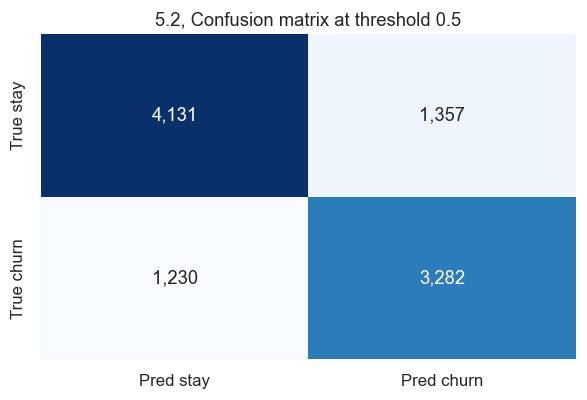

In [25]:
# One reporting helper so every model in Problem 2 is scored the same way.
# Accuracy alone is not enough even with near balanced classes, so precision, recall,
# F1 and ROC-AUC go in together with the raw confusion matrix counts.
# reference: Week 4 slides, "Why Accuracy Can Lie", "The Confusion Matrix",
#            "Precision - Don't Cry Wolf", "Recall - Don't Miss Anyone", "F1 Score"
def report(name, y_true, pred, proba):
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    out = {
        "model": name,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "f1": f1_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, proba),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }
    return out

res_lr = report("LogisticRegression", y_test, pred_lr, proba_lr)
for k, v in res_lr.items():
    print(f"  {k:10s} {v:.4f}" if isinstance(v, float) else f"  {k:10s} {v}")

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"\nBaseline (always predict the majority class): accuracy {baseline_acc:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
cm = confusion_matrix(y_test, pred_lr)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Pred stay", "Pred churn"], yticklabels=["True stay", "True churn"])
ax.set_title("5.2, Confusion matrix at threshold 0.5")
plt.tight_layout()
plt.show()

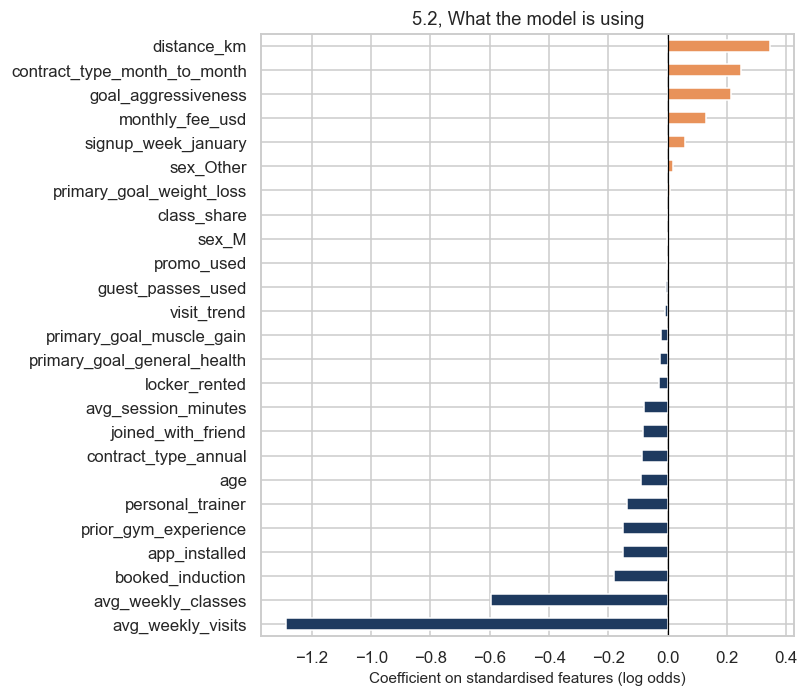

avg_weekly_visits              -1.289
avg_weekly_classes             -0.596
booked_induction               -0.180
app_installed                  -0.152
prior_gym_experience           -0.152
personal_trainer               -0.139
age                            -0.091
contract_type_annual           -0.087
joined_with_friend             -0.084
avg_session_minutes            -0.079
locker_rented                  -0.031
primary_goal_general_health    -0.025
primary_goal_muscle_gain       -0.021
visit_trend                    -0.008
guest_passes_used              -0.007
promo_used                     -0.002
sex_M                          -0.001
class_share                     0.001
primary_goal_weight_loss        0.006
sex_Other                       0.018
signup_week_january             0.058
monthly_fee_usd                 0.130
goal_aggressiveness             0.214
contract_type_month_to_month    0.248
distance_km                     0.345


In [26]:
# The pipeline standardises before fitting, so these coefficients are on a common
# scale and their sizes are directly comparable across features.
# reference: Week 5 slides, "Standardization (Z-score)"
# Standardised coefficients, so the sizes are comparable across features
coefs = pd.Series(logreg[-1].coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 6.5))
coefs.plot(kind="barh", ax=ax, color=[ACCENT if v > 0 else DARK for v in coefs])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient on standardised features (log odds)")
ax.set_title("5.2, What the model is using")
plt.tight_layout()
plt.show()
print(coefs.round(3).to_string())

**Interpretation (5.2):**

- Held out 10,000: accuracy 0.741, precision 0.707, recall 0.727, F1 0.717, AUC 0.822. The majority baseline is 0.549, so 19.2 points better than guessing.
- Confusion matrix at 0.5 is TN 4,131, FP 1,357, FN 1,230, TP 3,282, so it catches 3,282 of 4,512 churners.
- Against the client's criteria, finding three quarters of leavers with two thirds of alarms correct is enough for a retention campaign. Not enough to make an irreversible call on an individual member.
- Mostly reading behaviour. Standardised, `avg_weekly_visits` is -1.289 and `avg_weekly_classes` -0.596, an order of magnitude above the rest. Then `distance_km` +0.345, `contract_type_month_to_month` +0.248, `goal_aggressiveness` +0.214 and `monthly_fee_usd` +0.130. Fee is seventh, consistent with Phase 1.
- Two came out near zero that I expected to matter. `visit_trend` at -0.008 confirms 2.3, only the starting level distinguishes the groups. `class_share` at +0.001 adds nothing once visits and classes are known.

### 5.3: Threshold and ROC

 threshold  flagged_%  precision  recall    f1  missed_churners
      0.25       69.8      0.596   0.922 0.724              354
      0.30       65.4      0.618   0.895 0.731              473
      0.35       60.9      0.640   0.864 0.735              613
      0.40       56.3      0.660   0.823 0.732              799
      0.45       51.6      0.684   0.782 0.730              985
      0.50       46.4      0.707   0.727 0.717             1230
      0.55       41.1      0.731   0.666 0.697             1507
      0.60       36.0      0.756   0.603 0.671             1793
      0.65       30.6      0.779   0.529 0.630             2126


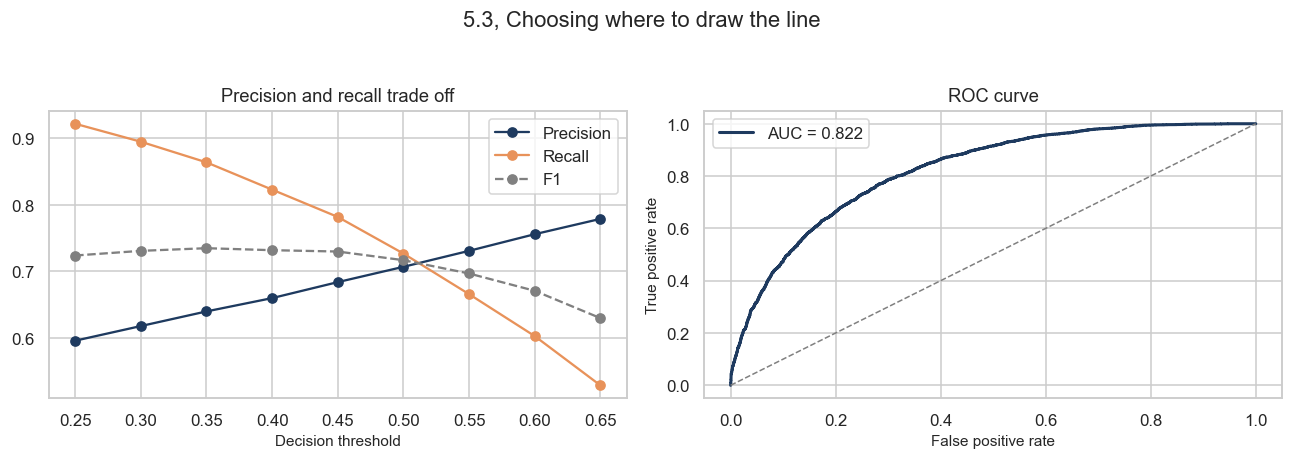

In [27]:
# reference: Week 7 slides, "We don't have to use 0.5" and "The ROC curve and AUC"
rows = []
for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
    p = (proba_lr >= t).astype(int)
    rows.append({
        "threshold": t,
        "flagged_%": round(p.mean() * 100, 1),
        "precision": round(precision_score(y_test, p), 3),
        "recall": round(recall_score(y_test, p), 3),
        "f1": round(f1_score(y_test, p), 3),
        "missed_churners": int(((y_test == 1) & (p == 0)).sum()),
    })
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))

fpr, tpr, _ = roc_curve(y_test, proba_lr)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sweep["threshold"], sweep["precision"], marker="o", color=DARK, label="Precision")
axes[0].plot(sweep["threshold"], sweep["recall"], marker="o", color=ACCENT, label="Recall")
axes[0].plot(sweep["threshold"], sweep["f1"], marker="o", color="grey", ls="--", label="F1")
axes[0].set_xlabel("Decision threshold")
axes[0].set_title("Precision and recall trade off")
axes[0].legend()

axes[1].plot(fpr, tpr, color=DARK, lw=2, label=f"AUC = {roc_auc_score(y_test, proba_lr):.3f}")
axes[1].plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()
fig.suptitle("5.3, Choosing where to draw the line", y=1.04)
plt.tight_layout()
plt.show()

**Interpretation (5.3):**

- 0.5 isnt the right threshold here. At 0.5 the model flags 46.4% and misses 1,230 churners. At 0.35 it flags 60.9% and misses 613, so halving the misses costs about 7 points of precision, 0.707 down to 0.640.
- The asymmetry decides it. A missed churner is a lost membership at about $53.90 a month. A false alarm is one email or a free class pass, near free for a gym that already employs staff.
- So Id run at 0.35, where F1 also peaks at 0.735. That catches 86.4% of leavers at the cost of contacting six in ten members.
- If the intervention were expensive, say a free PT session, Id go to 0.55 or 0.60 and keep precision above 0.73. The threshold is a business decision, and the model gives probabilities so leadership can pick their point.

### 5.4: Model comparison

In [28]:
# Does a more flexible model beat the linear one? Same split, same features, same
# threshold, so the only thing changing is the model family.
# reference: Week 4 slides, "Choosing a Model Type"
models = {"LogisticRegression": (pred_lr, proba_lr)}

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                            random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
models["RandomForest"] = ((proba_rf >= 0.5).astype(int), proba_rf)

gb = GradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
proba_gb = gb.predict_proba(X_test)[:, 1]
models["GradientBoosting"] = ((proba_gb >= 0.5).astype(int), proba_gb)

comparison = pd.DataFrame([report(n, y_test, p, pr) for n, (p, pr) in models.items()])
print(comparison.round(4).to_string(index=False))

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nRandom forest feature importances (top 10):")
print(imp.head(10).round(3).to_string())

             model  accuracy  precision  recall     f1  roc_auc   TN   FP   FN   TP
LogisticRegression    0.7413     0.7075  0.7274 0.7173   0.8215 4131 1357 1230 3282
      RandomForest    0.7383     0.7077  0.7154 0.7116   0.8185 4155 1333 1284 3228
  GradientBoosting    0.7384     0.7068  0.7181 0.7124   0.8205 4144 1344 1272 3240

Random forest feature importances (top 10):
avg_weekly_visits               0.388
avg_weekly_classes              0.139
class_share                     0.107
distance_km                     0.058
avg_session_minutes             0.042
monthly_fee_usd                 0.041
visit_trend                     0.041
contract_type_month_to_month    0.029
age                             0.026
goal_aggressiveness             0.022


**Interpretation (5.4):**

- No. Logistic regression AUC 0.822, gradient boosting 0.821, forest 0.819. Accuracy 0.741 against 0.738 for both trees, F1 0.717, 0.712 and 0.712.
- Three families within 0.003 usually means the signal is exhausted and the ceiling is in the data. 2.6 already showed that, no feature cleanly splits the population.
- The relationships are close to monotonic in the log odds so tree flexibility has nothing to bite on. Same conclusion as Assignment 2 for a different reason, there the forest overfit a small imbalanced set, here it has nothing extra to find.
- Importances agree on ranking except `class_share`, which the forest puts third while logistic gives it zero. Thats a tree artifact, a continuous ratio offers many split points which inflates impurity importance.
- So logistic regression stays as the deliverable. Equal accuracy, and the only one that answers the client's question.

### 5.5: Isolating the fee effect

                      model  n_predictors  fee_beta  OR_per_$1  OR_per_$10  CI_low_$10  CI_high_$10         p  pseudo_R2
              M1: fee alone             1   0.01852     1.0187      1.2035      1.1853       1.2219 1.39e-125     0.0084
        M2: + contract type             3   0.00759     1.0076      1.0788      1.0601       1.0979  1.91e-17     0.0173
 M3: + signup time controls            10   0.00805     1.0081      1.0838      1.0647       1.1032  6.97e-19     0.0389
M4: + first month behaviour            17   0.01078     1.0108      1.1138      1.0906       1.1375  1.11e-23     0.2688


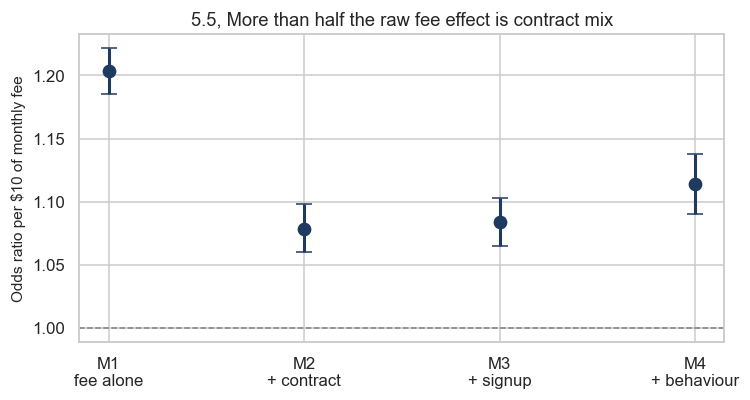

In [29]:
# Week 6: build up nested models and watch the fee coefficient move as confounders enter.
# reference: Week 6 slides, "Why coefficients change when you add predictors"
sm_df = pd.get_dummies(model_df, columns=["contract_type", "primary_goal", "sex"], drop_first=True)

FEE = ["monthly_fee_usd"]
CONTRACT = ["contract_type_annual", "contract_type_month_to_month"]
SIGNUP = ["distance_km", "age", "prior_gym_experience", "joined_with_friend",
          "goal_aggressiveness", "signup_week_january", "promo_used"]
BEHAVIOUR = ["avg_weekly_visits", "avg_weekly_classes", "avg_session_minutes",
             "booked_induction", "app_installed", "personal_trainer", "locker_rented"]

specs = [
    ("M1: fee alone", FEE),
    ("M2: + contract type", FEE + CONTRACT),
    ("M3: + signup time controls", FEE + CONTRACT + SIGNUP),
    ("M4: + first month behaviour", FEE + CONTRACT + SIGNUP + BEHAVIOUR),
]

fitted, rows = {}, []
for name, cols in specs:
    Xs = sm.add_constant(sm_df[cols].astype(float))
    m = sm.Logit(sm_df["churned_by_february"], Xs).fit(disp=0)
    fitted[name] = (m, Xs)
    b = m.params["monthly_fee_usd"]
    lo, hi = m.conf_int().loc["monthly_fee_usd"]
    rows.append({
        "model": name, "n_predictors": len(cols),
        "fee_beta": round(b, 5),
        "OR_per_$1": round(np.exp(b), 4),
        "OR_per_$10": round(np.exp(10 * b), 4),
        "CI_low_$10": round(np.exp(10 * lo), 4),
        "CI_high_$10": round(np.exp(10 * hi), 4),
        "p": f"{m.pvalues['monthly_fee_usd']:.2e}",
        "pseudo_R2": round(m.prsquared, 4),
    })
nested = pd.DataFrame(rows)
print(nested.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.errorbar(range(4), nested["OR_per_$10"],
            yerr=[nested["OR_per_$10"] - nested["CI_low_$10"],
                  nested["CI_high_$10"] - nested["OR_per_$10"]],
            fmt="o", color=DARK, capsize=5, lw=2, markersize=8)
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.set_xticks(range(4))
ax.set_xticklabels(["M1\nfee alone", "M2\n+ contract", "M3\n+ signup", "M4\n+ behaviour"])
ax.set_ylabel("Odds ratio per $10 of monthly fee")
ax.set_title("5.5, More than half the raw fee effect is contract mix")
plt.tight_layout()
plt.show()

In [30]:
# How much does the fee add on top of everything else? Refit M3 without it and
# compare pseudo R2. A coefficient can be significant and still explain almost nothing.
# reference: Week 6 slides, "R2 - how well does the model fit?"
# What does the fee add over and above everything else? Drop it from M3 and compare.
m3, X3 = fitted["M3: + signup time controls"]
cols_nofee = [c for c in FEE + CONTRACT + SIGNUP if c != "monthly_fee_usd"]
m3_nofee = sm.Logit(sm_df["churned_by_february"],
                    sm.add_constant(sm_df[cols_nofee].astype(float))).fit(disp=0)
print(f"M3 pseudo R2 with fee   : {m3.prsquared:.4f}")
print(f"M3 pseudo R2 without fee: {m3_nofee.prsquared:.4f}")
print(f"Fee's unique contribution: {m3.prsquared - m3_nofee.prsquared:.4f}")

print("\nFull M3 coefficient table (odds ratios):")
tbl = pd.DataFrame({
    "beta": m3.params,
    "odds_ratio": np.exp(m3.params),
    "p_value": m3.pvalues,
}).round(4)
print(tbl.to_string())

M3 pseudo R2 with fee   : 0.0389
M3 pseudo R2 without fee: 0.0378
Fee's unique contribution: 0.0011

Full M3 coefficient table (odds ratios):
                                beta  odds_ratio  p_value
const                        -1.2623      0.2830   0.0000
monthly_fee_usd               0.0080      1.0081   0.0000
contract_type_annual         -0.3601      0.6976   0.0000
contract_type_month_to_month  0.3680      1.4448   0.0000
distance_km                   0.0558      1.0574   0.0000
age                          -0.0063      0.9937   0.0000
prior_gym_experience         -0.2036      0.8158   0.0000
joined_with_friend           -0.2963      0.7435   0.0000
goal_aggressiveness           0.1354      1.1450   0.0000
signup_week_january           0.0402      1.0410   0.0000
promo_used                   -0.0018      0.9982   0.9207


**Interpretation (5.5):**

- Fee alone says every $10 multiplies the odds of churning by 1.2035. Adding two contract dummies cuts it to 1.0788, so more than half disappears.
- Nothing else moves it. Distance, age, prior experience, friend, goal aggressiveness, signup week and promo leave it at 1.0838, with a 95% CI of [1.065, 1.103].
- Thats the Week 6 mechanism. Month to month is both most expensive and least committed, so the simple comparison glued commitment and price together. The fee keeps about 39% of what it claimed.
- M4 is a different question. Behaviour lifts it to 1.1138 because visits and classes sit between fee and outcome, so controlling for them blocks part of the route. Post treatment problem from Assignment 2 again. M3 is the number to quote, M4 a diagnostic, and their closeness says the fee isnt working mainly through attendance.
- Fee adds 0.0011 of pseudo R2 to M3's 0.0389. Real and precisely estimated, and tiny as a share of what makes members churn.

### 5.6: From odds ratios to percentage points

In [31]:
# An odds ratio is not something leadership can act on. Convert to average marginal effect,
# which is the change in probability of churn, averaged over every member in the data.
# reference: Week 7 slides, "From probability to odds" (run in reverse)
def fee_effects(model, Xmat, cut):
    beta = model.params["monthly_fee_usd"]
    p0 = model.predict(Xmat)
    Xc = Xmat.copy()
    Xc["monthly_fee_usd"] = Xc["monthly_fee_usd"] - cut
    p1 = model.predict(Xc)
    ame = (beta * p0 * (1 - p0)).mean()
    return p0.mean(), p1.mean(), ame

for name in ["M3: + signup time controls", "M4: + first month behaviour"]:
    m, Xm = fitted[name]
    p0, p1, ame = fee_effects(m, Xm, cut=10)
    print(f"\n{name}")
    print(f"  average marginal effect: {ame*100:.3f} pp per $1  |  {ame*1000:.2f} pp per $10")
    print(f"  cut every fee by $10   : churn {p0*100:.2f}% -> {p1*100:.2f}%  ({(p1-p0)*100:+.2f} pp)")
    print(f"  members retained       : {(p0-p1)*len(sm_df):,.0f} of {len(sm_df):,}")


M3: + signup time controls
  average marginal effect: 0.189 pp per $1  |  1.89 pp per $10
  cut every fee by $10   : churn 45.12% -> 43.24%  (-1.88 pp)
  members retained       : 941 of 50,000

M4: + first month behaviour
  average marginal effect: 0.181 pp per $1  |  1.81 pp per $10
  cut every fee by $10   : churn 45.12% -> 43.31%  (-1.81 pp)
  members retained       : 907 of 50,000


Bootstrap over 300 resamples, odds ratio per $10:
  mean 1.0834, 95% interval [1.0671, 1.1040]
  analytic M3 estimate for comparison: 1.0838


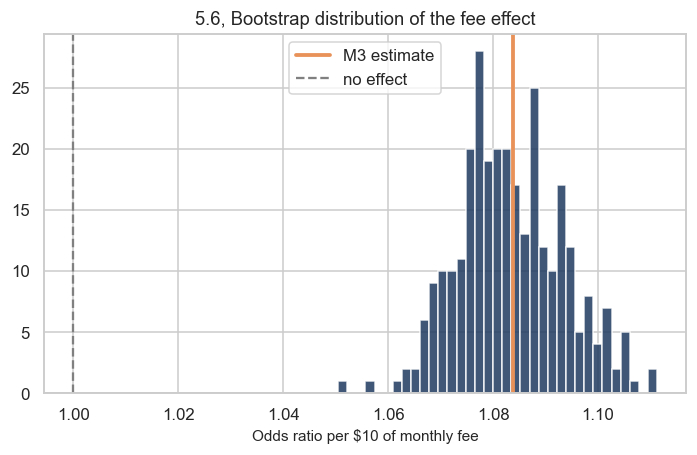

In [32]:
# Bootstrap the M3 fee coefficient so the estimate carries its own uncertainty.
# reference: Week 6 slides, "Bootstrap - measuring uncertainty"
rng = np.random.default_rng(RANDOM_STATE)
Xv, yv = X3.values, sm_df["churned_by_february"].values
boot = []
for _ in range(300):
    idx = rng.integers(0, len(Xv), len(Xv))
    try:
        boot.append(sm.Logit(yv[idx], Xv[idx]).fit(disp=0).params[1])
    except Exception:
        pass
boot = np.array(boot)
or10 = np.exp(10 * boot)
print(f"Bootstrap over {len(boot)} resamples, odds ratio per $10:")
print(f"  mean {or10.mean():.4f}, 95% interval [{np.percentile(or10,2.5):.4f}, {np.percentile(or10,97.5):.4f}]")
print(f"  analytic M3 estimate for comparison: {np.exp(10*m3.params['monthly_fee_usd']):.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.hist(or10, bins=35, color=DARK, alpha=0.85)
ax.axvline(np.exp(10 * m3.params["monthly_fee_usd"]), color=ACCENT, lw=2.5, label="M3 estimate")
ax.axvline(1.0, color="grey", ls="--", lw=1.5, label="no effect")
ax.set_xlabel("Odds ratio per $10 of monthly fee")
ax.set_title("5.6, Bootstrap distribution of the fee effect")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (5.6):**

- An odds ratio isnt usable in a leadership meeting, so I convert it. The average marginal effect under M3 is 0.189 points of churn per $1, or 1.89 points per $10.
- A $10 cut for everyone moves predicted churn from 45.12% to 43.24%, so 941 members retained out of 50,000.
- The bootstrap agrees. Over 300 resamples the mean odds ratio per $10 is 1.0834 against the M3 estimate of 1.0838, interval [1.067, 1.104], entirely above 1.
- Its small though. About 940 saved out of 22,560 leavers is roughly 4% of the problem, for a price cut given to all 50,000.

### 5.7: The pricing answer, retained revenue across the fee range

In [33]:
# reference: Week 7 slides, "From probability to odds" (run in reverse, back to a
#            probability), and Week 6 "Statistical vs. practical significance"
# The client's objective: retained revenue = fee x P(stay), optimised inside the fee range
# that exists in the data. They also want one overall rate, not a segmented set of rates.
# Every figure is produced twice, raw and adjusted for contract type, so the commitment
# effect cannot be mistaken for a price effect.
m_raw, X_raw = fitted["M1: fee alone"]
m_adj, X_adj = fitted["M3: + signup time controls"]

fee_lo, fee_hi = model_df["monthly_fee_usd"].min(), model_df["monthly_fee_usd"].max()
fee_now = model_df["monthly_fee_usd"].mean()
print(f"Observed fee range: ${fee_lo:.2f} to ${fee_hi:.2f}. Current mean: ${fee_now:.2f}")

def sweep_flat_fee(model, Xmat, grid):
    out = []
    for f in grid:
        Xc = Xmat.copy()
        Xc["monthly_fee_usd"] = f
        p_stay = (1 - model.predict(Xc)).mean()
        out.append({"fee": f, "p_stay": p_stay, "retained_rev": f * p_stay})
    return pd.DataFrame(out)

grid = np.arange(np.ceil(fee_lo), fee_hi + 0.01, 0.25)
sweep_raw = sweep_flat_fee(m_raw, X_raw, grid)
sweep_adj = sweep_flat_fee(m_adj, X_adj, grid)

# Where does retained revenue actually stand today?
p_stay_now = 1 - m_adj.predict(X_adj)
rr_now = (model_df["monthly_fee_usd"] * p_stay_now).mean()
print(f"Retained revenue today: ${rr_now:.2f} per member per month "
      f"(stay probability {p_stay_now.mean():.4f})")

for name, sw in [("RAW, fee only", sweep_raw), ("ADJUSTED, contract + promo + signup", sweep_adj)]:
    best = sw.loc[sw["retained_rev"].idxmax()]
    interior = best["fee"] < grid[-1] - 0.5
    print(f"\n{name}")
    print(f"  peak retained revenue ${best['retained_rev']:.2f} at a flat fee of ${best['fee']:.2f} "
          f"(stay probability {best['p_stay']:.4f})")
    print(f"  is the peak interior to the observed range? {interior}")
    print(f"  value at the top of the range (${grid[-1]:.2f}): ${sw['retained_rev'].iloc[-1]:.2f}")

Observed fee range: $15.00 to $101.89. Current mean: $53.90


Retained revenue today: $28.96 per member per month (stay probability 0.5488)

RAW, fee only
  peak retained revenue $34.61 at a flat fee of $88.50 (stay probability 0.3911)
  is the peak interior to the observed range? True
  value at the top of the range ($101.75): $34.03

ADJUSTED, contract + promo + signup
  peak retained revenue $46.58 at a flat fee of $101.75 (stay probability 0.4578)
  is the peak interior to the observed range? False
  value at the top of the range ($101.75): $46.58


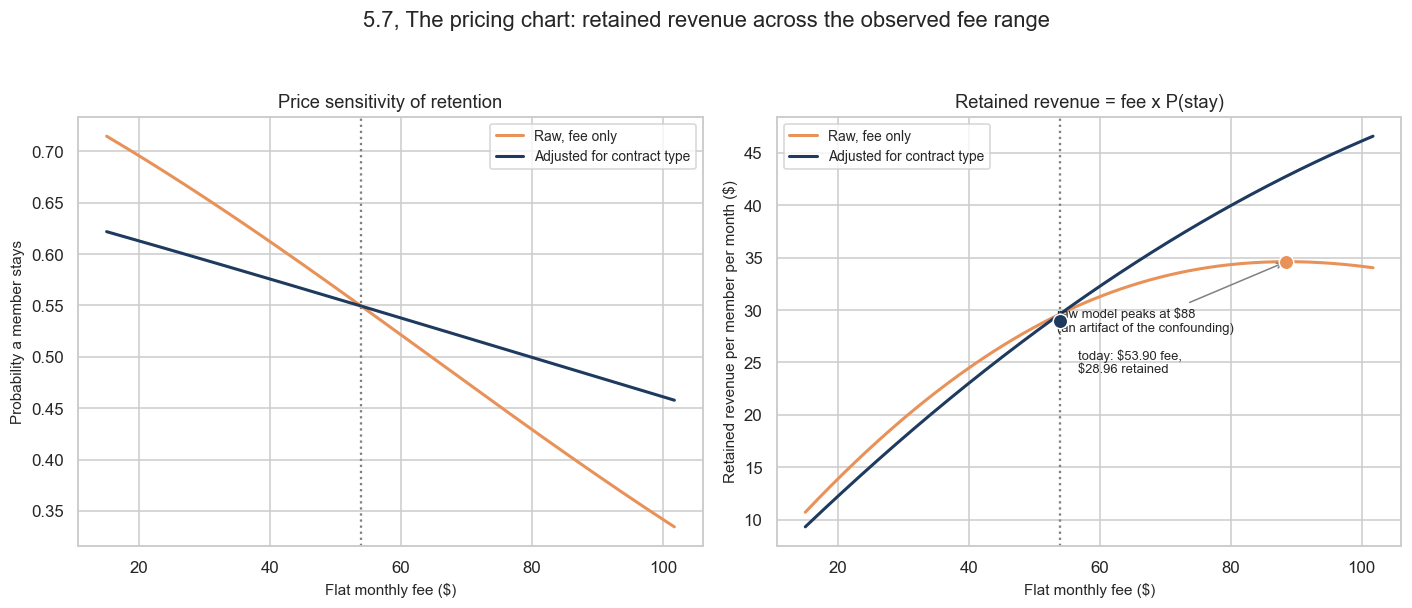

In [34]:
# reference: Week 6 slides, "Why coefficients change when you add predictors"
#            (the raw curve is what that slide warns about, drawn out)
# The pricing chart. The client asked for this regardless of what Phase 1 concluded.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))

axes[0].plot(sweep_raw["fee"], sweep_raw["p_stay"], lw=2, color=ACCENT, label="Raw, fee only")
axes[0].plot(sweep_adj["fee"], sweep_adj["p_stay"], lw=2, color=DARK, label="Adjusted for contract type")
axes[0].axvline(fee_now, color="grey", ls=":", lw=1.5)
axes[0].set_xlabel("Flat monthly fee ($)")
axes[0].set_ylabel("Probability a member stays")
axes[0].set_title("Price sensitivity of retention")
axes[0].legend(fontsize=9)

axes[1].plot(sweep_raw["fee"], sweep_raw["retained_rev"], lw=2, color=ACCENT, label="Raw, fee only")
axes[1].plot(sweep_adj["fee"], sweep_adj["retained_rev"], lw=2, color=DARK, label="Adjusted for contract type")
best_raw = sweep_raw.loc[sweep_raw["retained_rev"].idxmax()]
axes[1].scatter([best_raw["fee"]], [best_raw["retained_rev"]], s=90, color=ACCENT,
                edgecolor="white", zorder=5)
axes[1].annotate(f"raw model peaks at ${best_raw['fee']:.0f}\n(an artifact of the confounding)",
                 xy=(best_raw["fee"], best_raw["retained_rev"]), xytext=(-150, -46),
                 textcoords="offset points", fontsize=8.5,
                 arrowprops=dict(arrowstyle="->", color="grey", lw=1))
axes[1].axvline(fee_now, color="grey", ls=":", lw=1.5)
axes[1].scatter([fee_now], [rr_now], s=90, color=DARK, edgecolor="white", zorder=5)
axes[1].annotate(f"today: ${fee_now:.2f} fee,\n${rr_now:.2f} retained",
                 xy=(fee_now, rr_now), xytext=(12, -34), textcoords="offset points", fontsize=8.5)
axes[1].set_xlabel("Flat monthly fee ($)")
axes[1].set_ylabel("Retained revenue per member per month ($)")
axes[1].set_title("Retained revenue = fee x P(stay)")
axes[1].legend(fontsize=9, loc="upper left")

fig.suptitle("5.7, The pricing chart: retained revenue across the observed fee range", y=1.04)
plt.tight_layout()
plt.show()

**Interpretation (5.7):**

- Today FitnessPlanet retains $28.96 per member per month, from a mean fee of $53.90 and a stay probability of 0.549.
- On the adjusted model theres no interior optimum. Retained revenue rises the whole way, $9.33 at a $15 flat fee up to $46.58 at the top of the range. Every $10 costs about 1.89 points of stay probability and adds a full $10 of billing, so the price response is real and just not steep enough to bend the curve down.
- The raw model invents an optimum that isnt there, which is the trap the client named. On fee alone it peaks at $88.50 and declines after. That looks like a sweet spot and its a confounding artifact, the unadjusted coefficient overstates price sensitivity by about 2.3 times (0.0185 against 0.0081).
- So the one rate is hold current pricing at a mean of $53.90, with any move down ruled out. The curve points up but I wont recommend a rise, and thats a hard limit rather than caution: every member in this file already signed up, so it cannot see how price affects whether people join at all.

### 5.8: What a price cut would cost

In [35]:
# reference: Week 6 slides, "Statistical vs. practical significance" (p said the fee
#            effect is real, this asks whether it is big enough to act on)
# The business question: does the retention gained pay for the revenue given up?
# Churners ghost by end of February, so they contribute roughly 2 months of fees.
# Stayers contribute the full 12. This is the simplest defensible year one model.
from scipy.optimize import brentq

MONTHS_IF_CHURN, MONTHS_IF_STAY = 2, 12

def year_one_revenue(cut):
    Xc = X3.copy()
    Xc["monthly_fee_usd"] = Xc["monthly_fee_usd"] - cut
    p = m3.predict(Xc)
    fee_new = (model_df["monthly_fee_usd"] - cut).clip(lower=0)
    rev = (fee_new * (p * MONTHS_IF_CHURN + (1 - p) * MONTHS_IF_STAY)).sum()
    return p.mean(), rev

p_base, rev_base = year_one_revenue(0)
rows = []
for cut in [0, 5, 10, 15, 20]:
    pm, rev = year_one_revenue(cut)
    rows.append({
        "fee_cut": f"${cut}",
        "predicted_churn": f"{pm*100:.2f}%",
        "churn_change_pp": round((pm - p_base) * 100, 2),
        "members_retained": int(round((p_base - pm) * len(model_df))),
        "year1_fee_revenue": f"${rev:,.0f}",
        "revenue_change": f"${rev - rev_base:+,.0f}",
    })
print(pd.DataFrame(rows).to_string(index=False))

# Break even: how far would churn have to fall for a $10 cut to hold revenue flat?
fee_10 = (model_df["monthly_fee_usd"] - 10).clip(lower=0)
solve = lambda q: (fee_10 * (q * MONTHS_IF_CHURN + (1 - q) * MONTHS_IF_STAY)).sum() - rev_base
q_break = brentq(solve, 0.0, p_base)
p_10, _ = year_one_revenue(10)

print(f"\nBaseline: churn {p_base*100:.2f}%, year one fee revenue ${rev_base:,.0f}")
print(f"A $10 cut BREAKS EVEN only if churn falls to {q_break*100:.2f}%, "
      f"a drop of {(p_base-q_break)*100:.1f} pp")
print(f"The model says a $10 cut actually delivers {(p_base-p_10)*100:.2f} pp")
print(f"Required / delivered = {(p_base-q_break)/(p_base-p_10):.1f}x")

fee_cut predicted_churn  churn_change_pp  members_retained year1_fee_revenue revenue_change
     $0          45.12%             0.00                 0       $19,868,225            $+0
     $5          44.18%            -0.94               471       $18,228,463    $-1,639,762
    $10          43.24%            -1.88               941       $16,540,907    $-3,327,318
    $15          42.30%            -2.82              1408       $14,805,727    $-5,062,499
    $20          41.38%            -3.74              1872       $13,023,963    $-6,844,263

Baseline: churn 45.12%, year one fee revenue $19,868,225
A $10 cut BREAKS EVEN only if churn falls to 29.49%, a drop of 15.6 pp
The model says a $10 cut actually delivers 1.88 pp
Required / delivered = 8.3x


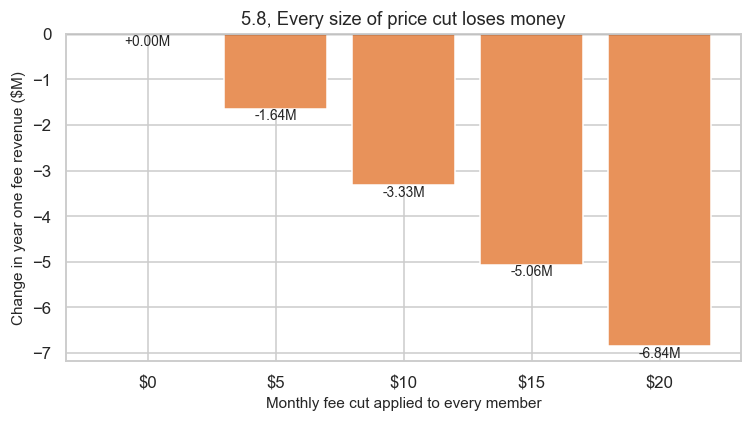

In [36]:
# Same numbers as the table above, drawn so the direction is obvious at a glance.
fig, ax = plt.subplots(figsize=(7, 4))
cuts = [0, 5, 10, 15, 20]
deltas = [year_one_revenue(c)[1] - rev_base for c in cuts]
ax.bar([f"${c}" for c in cuts], np.array(deltas) / 1e6, color=[DARK] + [ACCENT] * 4)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Monthly fee cut applied to every member")
ax.set_ylabel("Change in year one fee revenue ($M)")
ax.set_title("5.8, Every size of price cut loses money")
for i, v in enumerate(np.array(deltas) / 1e6):
    ax.text(i, v - 0.25, f"{v:+.2f}M", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation (5.8):**

- No, and not close. Year one fee revenue at current pricing is $19.87M, assuming a churner pays two months and a stayer twelve.
- A $10 cut gives 43.24% churn and $16.54M, which is $3.33M worse. Every size loses money: $5 costs $1.64M, $10 costs $3.33M, $15 costs $5.06M, $20 costs $6.84M.
- The break even is the clearest framing. For a $10 cut to pay for itself churn would have to fall from 45.12% to 29.49%, a drop of 15.6 points. It delivers 1.88. The required effect is 8.3 times larger than the real one.
- It doesnt fail because the effect is noise. It fails because the discount goes to all 50,000 members while the gain lands on about 940.
- The one narrow version worth testing is a targeted offer to high fee month to month members, and Id run that as a trial rather than infer it here.

### 5.9: The alternative the data actually points to

In [37]:
# reference: Week 4 slides, "The Train / Test Split" (same split and metric as 5.2,
#            so the two AUCs are comparable)
# Sections 2.3 and 5.2 both say the split is visible in week 1. Can I predict churn
# using ONLY facts the gym has on day 7, so a retention team can act inside the month?
early_feats = [
    "monthly_fee_usd", "distance_km", "age", "goal_aggressiveness", "signup_week_january",
    "promo_used", "prior_gym_experience", "joined_with_friend", "booked_induction",
    "personal_trainer", "app_installed", "locker_rented", "week1_visits",
]
X_early = pd.concat([model_df[early_feats], cat_feats], axis=1)
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(
    X_early, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
early = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)).fit(Xe_tr, ye_tr)
proba_e = early.predict_proba(Xe_te)[:, 1]
print(f"Week 1 early warning model, AUC = {roc_auc_score(ye_te, proba_e):.3f} "
      f"(full month model was {roc_auc_score(y_test, proba_lr):.3f})")

# And the day 0 version, signup facts only, no behaviour at all
X_day0 = pd.concat([model_df[[f for f in early_feats if f != "week1_visits"]], cat_feats], axis=1)
X0_tr, X0_te, _, _ = train_test_split(X_day0, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
day0 = make_pipeline(StandardScaler(),
                     LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)).fit(X0_tr, ye_tr)
print(f"Day 0 model, signup facts only,  AUC = {roc_auc_score(ye_te, day0.predict_proba(X0_te)[:,1]):.3f}")

print("\nEarly warning model at different thresholds:")
for t in [0.40, 0.45, 0.50, 0.55]:
    p = (proba_e >= t).astype(int)
    print(f"  t={t}: flags {p.mean()*100:.1f}% of members, precision {precision_score(ye_te,p):.3f}, "
          f"recall {recall_score(ye_te,p):.3f}")

print("\nAnd the simplest possible rule, no model at all:")
for k in [0, 1, 2]:
    flag = model_df["week1_visits"] <= k
    print(f"  'week 1 visits <= {k}': flags {flag.mean()*100:.1f}% of members, "
          f"churn among flagged {model_df.loc[flag,'churned_by_february'].mean():.3f}, "
          f"catches {model_df.loc[flag,'churned_by_february'].sum()/n_churn*100:.1f}% of all churners")

Week 1 early warning model, AUC = 0.755 (full month model was 0.822)
Day 0 model, signup facts only,  AUC = 0.658

Early warning model at different thresholds:
  t=0.4: flags 58.4% of members, precision 0.608, recall 0.787
  t=0.45: flags 52.0% of members, precision 0.629, recall 0.725
  t=0.5: flags 44.8% of members, precision 0.651, recall 0.646
  t=0.55: flags 37.8% of members, precision 0.673, recall 0.564

And the simplest possible rule, no model at all:
  'week 1 visits <= 0': flags 12.8% of members, churn among flagged 0.713, catches 20.2% of all churners
  'week 1 visits <= 1': flags 33.3% of members, churn among flagged 0.654, catches 48.3% of all churners
  'week 1 visits <= 2': flags 53.8% of members, churn among flagged 0.601, catches 71.8% of all churners


**Interpretation (5.9):**

- A model knowing only the signup paperwork plus week 1 attendance reaches AUC 0.755, against 0.822 for the full month model. So three extra weeks buys 0.067 of AUC and gives up three of the eight weeks available to intervene.
- Signup facts alone reach 0.658. Not actionable on its own but well above chance, so part of the risk arrives with the member.
- The simplest version needs no model. Members who visited once or less in week 1 are 33.3% of the cohort, they churn at 65.4%, and they contain 48.3% of every churner. A front desk can pull that list on the 8th of January.
- Thats what Id fund instead. A and B spend on members already staying, C spends on all 50,000 to save about 940, and a week 1 trigger spends on a third of the cohort holding half the churn while theres still time.
- I havent costed the intervention itself, which is the honest limit here.

### 5.10: Appendix, the segmented view

In [38]:
# reference: Week 6 slides, "Why coefficients change when you add predictors"
#            (refit on one segment to see whether the fee coefficient moves)
# The client asked for one overall rate, with segmented results kept to an appendix, and
# explicitly no segmentation by age or gender. Age and sex remain in the model as controls
# only, they are never used to split a recommendation.
mm = model_df[model_df["contract_type"] == "month_to_month"].copy()
print(f"month_to_month segment: {len(mm):,} members ({len(mm)/len(model_df)*100:.1f}% of the base), "
      f"churn {mm['churned_by_february'].mean():.3f}, mean fee ${mm['monthly_fee_usd'].mean():.2f}")

mm_d = pd.get_dummies(mm, columns=["primary_goal", "sex"], drop_first=True)
seg_cols = ["monthly_fee_usd", "promo_used", "distance_km", "age", "prior_gym_experience",
            "joined_with_friend", "goal_aggressiveness", "signup_week_january"]
X_mm = sm.add_constant(mm_d[seg_cols].astype(float))
m_mm = sm.Logit(mm_d["churned_by_february"], X_mm).fit(disp=0)

b_mm = m_mm.params["monthly_fee_usd"]
p_mm = m_mm.predict(X_mm)
ame_mm = (b_mm * p_mm * (1 - p_mm)).mean()
b_all = m_adj.params["monthly_fee_usd"]
p_all = m_adj.predict(X_adj)
ame_all = (b_all * p_all * (1 - p_all)).mean()

print(f"\n{'':22s} {'OR per $10':>12s} {'AME per $10':>14s}")
print(f"{'all members (5.5 M3)':22s} {np.exp(10*b_all):>12.4f} {ame_all*1000:>13.2f} pp")
print(f"{'month_to_month only':22s} {np.exp(10*b_mm):>12.4f} {ame_mm*1000:>13.2f} pp")

print("\nChurn by fee quintile within month_to_month:")
print(mm.groupby("fee_q", observed=True)["churned_by_february"].agg(["mean", "size"]).round(3))

month_to_month segment: 31,220 members (62.4% of the base), churn 0.504, mean fee $58.08

                         OR per $10    AME per $10
all members (5.5 M3)         1.0838          1.89 pp
month_to_month only          1.0894          2.08 pp

Churn by fee quintile within month_to_month:
                  mean  size
fee_q                       
(14.999, 43.76]  0.453  2969
(43.76, 50.61]   0.482  4848
(50.61, 56.8]    0.497  6335
(56.8, 63.89]    0.521  7817
(63.89, 101.89]  0.522  9251


**Interpretation (5.10):**

- Barely, which is why this is an appendix.
- Month to month is 62.4% of the base, churns at 50.4% against 45.1% overall, carries the highest mean fee at $58.08, and was the only contract type where a fee gradient survived 4.3.
- Fitting the adjusted model on it alone gives an odds ratio of 1.0894 per $10 against 1.0838 for the full base, and an AME of 2.08 points against 1.89. About ten percent more price sensitivity in the segment that has the most of it.
- That doesnt change 5.7. Even at 2.08 points per $10, retained revenue in this segment still rises with fee.
- So the client's one overall value is the right call. The segment with the strongest price response behaves like the whole base, theres no hidden pocket of price sensitive members.
- No results are broken out by age or sex anywhere, per the client. Both stay as controls only.

### 5.11: The pilot I would propose

**Interpretation (5.11):**

- Everything above is observational. Members werent randomly assigned a fee, so 5.7 describes the members FitnessPlanet has rather than showing that moving the price would move them.
- The biggest gap is acquisition. All 50,000 already agreed to the price, so the file is silent on anyone who saw the fee and didnt join. A retention only analysis will always point upward, which is a property of the data and not a finding.
- Design: next January's intake randomised at signup into control at current pricing, one arm about 10% above to measure what it costs in signups, and one about 10% below to test the cut directly.
- Record signup rate per arm first, which this dataset cannot give, then `churned_by_february` and retained revenue per member. One January answers it.
- Keep contract mix balanced across arms or the trial reproduces the confounding 5.5 had to correct, and apply the change at signup rather than repricing existing members.
- Alongside it, 5.9 costs nothing to run and addresses the half of the problem pricing doesnt touch.